## Loading of Stringer orientations data

includes some visualizations

In [1]:

# @title Install depedencies
!pip install umap-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
# from umap import UMAP
from scipy.ndimage import uniform_filter1d
from scipy.stats import zscore
from sklearn.decomposition import PCA
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn as nn
import torch.optim as optim
from scipy.stats import pearsonr
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
from tensorflow.keras.regularizers import l2
import plotly.express as px
from sklearn.cluster import KMeans
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from torch.nn import functional as F
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, RidgeCV
from kan import KAN

!pip install pykan

!git clone https://github.com/KindXiaoming/pykan.git
!cd pykan
!pip install -e .
!pip install scikit_learn

from kan import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 1.8 MB/s eta 0:00:00
Cloning into 'pykan'...
remote: Enumerating objects: 4205, done.
remote: Counting objects: 100% (1771/1771), done.
remote: Compressing objects: 100% (868/868), done.
remote: Total 4205 (delta 1040), reused 1539 (delta 899), pack-reused 2434 (from 1)
Receiving objects: 100% (4205/4205), 114.69 MiB | 47.13 MiB/s, done.
Resolving deltas: 100% (1575/1575), done.
Obtaining file:///content
ERROR: file:///content does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
cpu


In [ ]:
# Normalize the data
def zscore(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1  # Avoid division by zero
    return (data - mean) / std

# Handling NaN values in the dataset by replacing with mean
def handle_na(data):
    df = pd.DataFrame(data)
    df.fillna(df.mean(), inplace=True)
    return df.to_numpy()

In [3]:
#@title Data retrieval
import os, requests

fname = "stringer_orientations.npy"
url = "https://osf.io/ny4ut/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [4]:
# @title Figure settings
from matplotlib import rcParams

rcParams['figure.figsize'] = [20, 4]
rcParams['font.size'] = 15
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

In [5]:
# @title Data loading

dat = np.load('stringer_orientations.npy', allow_pickle=True).item()
print(dat.keys())

dict_keys(['sresp', 'istim', 'stat', 'u_spont', 'v_spont', 'mean_spont', 'std_spont', 'stimtimes', 'frametimes', 'camtimes', 'run', 'info', 'xyz'])


dat has fields:
* `dat['sresp']`: neurons by stimuli, a.k.a. the neural response data (23589 by 4598)
* `dat['xyz']`: three-dimensional position of each neuron in the brain.
* `dat['run']`: 1 by stimuli, a.k.a. the running speed of the animal in a.u.
* `dat['istim']`: 1 by stimuli, goes from 0 to 2*np.pi, the orientations shown on each trial
* `dat['u_spont']`: neurons by 128, the weights for the top 128 principal components of spontaneous activity. Unit norm.
* `dat['v_spont']`: 128 by 910, the timecourses for the top 128 PCs of spont activity.
* `dat['u_spont'] @ dat['v_spont']`: a reconstruction of the spontaneous activity for 910 timepoints interspersed throughout the recording.
* `dat['stat']`: 1 by neurons, some statistics for each neuron, see Suite2p for full documentation.

In [6]:
print(dat['sresp'].shape)
print(len(dat['stat']))

print(dat['xyz'].shape)
print(dat['run'].shape)
print(dat['istim'].shape)
print(dat['u_spont'].shape)
print(dat['v_spont'].shape)
# print(dat['u_spont'] @ dat['v_spont'])

# acceleration = dat['run'][1:] - dat['run'][:-1]
# # acceleration = np.derivative(dat['run'])
# acceleration = np.vstack([acceleration[0], acceleration])
# print(acceleration.shape)

# Extract the running speed data from the dat dictionary
run = dat['run']

# Compute the rate-of-change derivative to get the acceleration
# Assuming 'run' is a 1D array, where run[i] corresponds to the running speed at timepoint i
acceleration = np.diff(run, prepend=run[0])

stim_der = np.diff(dat['istim'], prepend=dat['istim'][0])
print(stim_der.shape)

# Print the shapes to verify
print("Shape of run:", run.shape)
print("Shape of acceleration:", acceleration.shape)
sresp = dat['sresp']
i_stim = dat['istim']
run = dat['run']

sresp_der = np.diff(dat['sresp'], axis=0)
print(sresp_der.shape)

(23589, 4598)
23589
(3, 23589)
(4598,)
(4598,)
(23589, 128)
(128, 910)
(4598,)
Shape of run: (4598,)
Shape of acceleration: (4598,)
(23588, 4598)


(23588, 4598)
[[ 1.         -0.06517276]
 [-0.06517276  1.        ]]


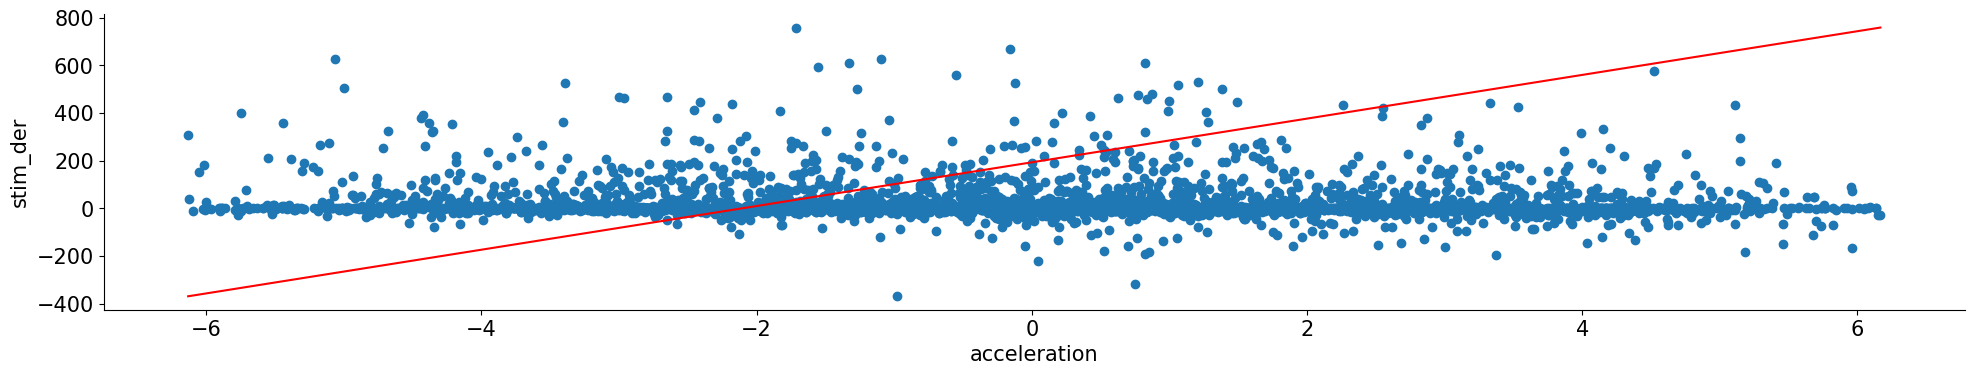

-0.06517275545453768
9.744297097529079e-06


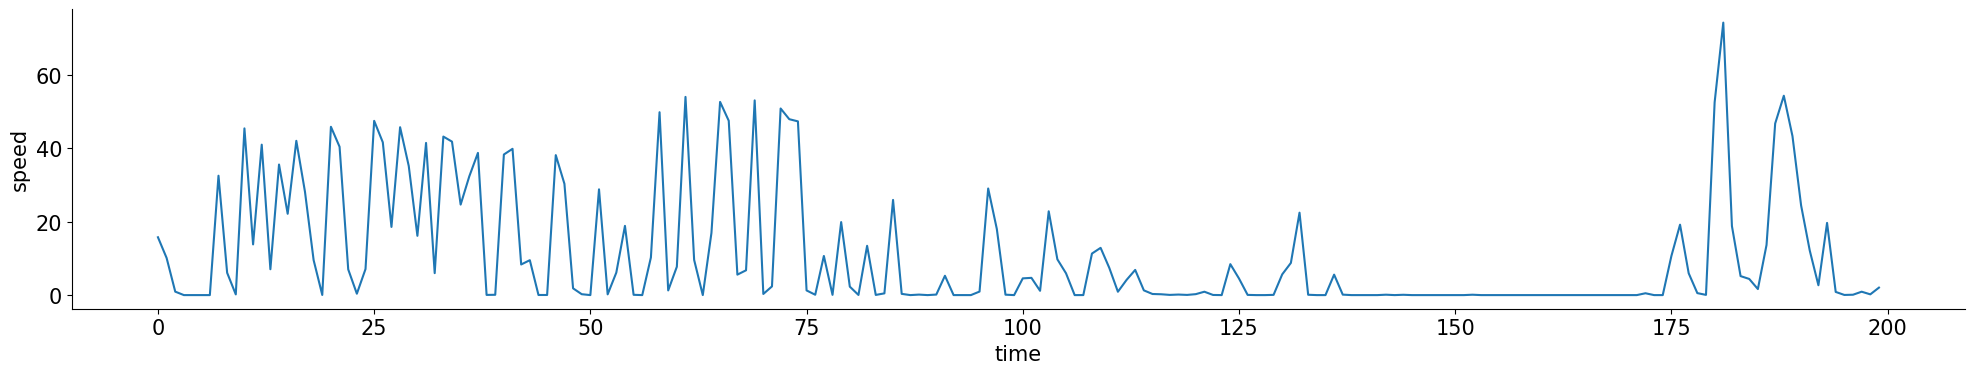

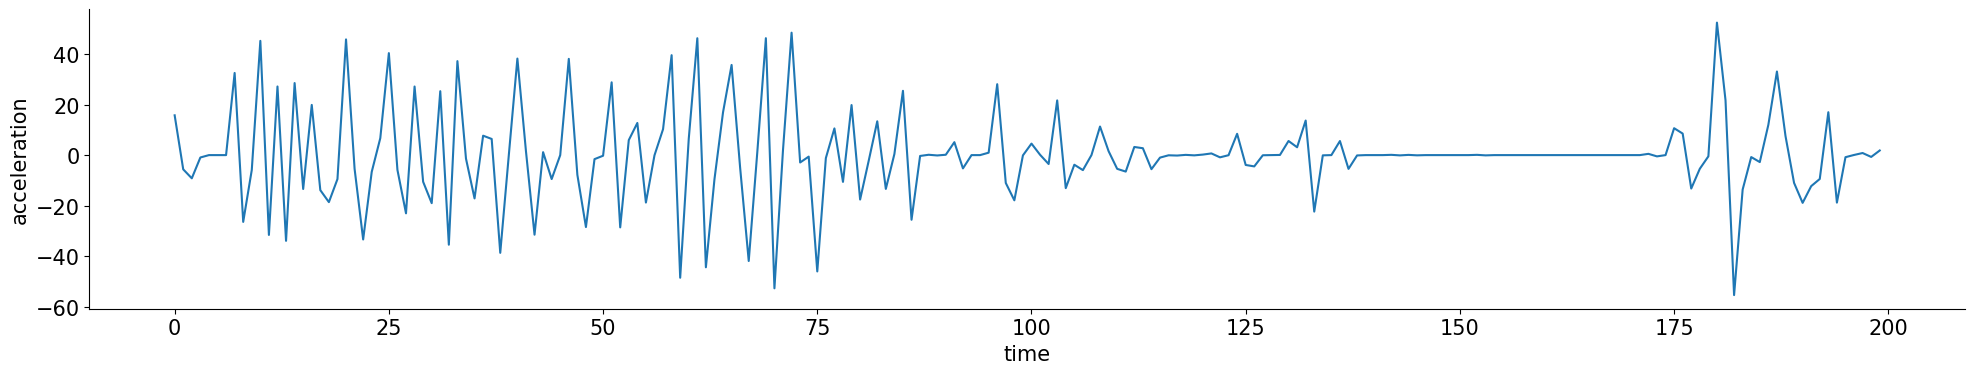

/usr/local/lib/python3.10/dist-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


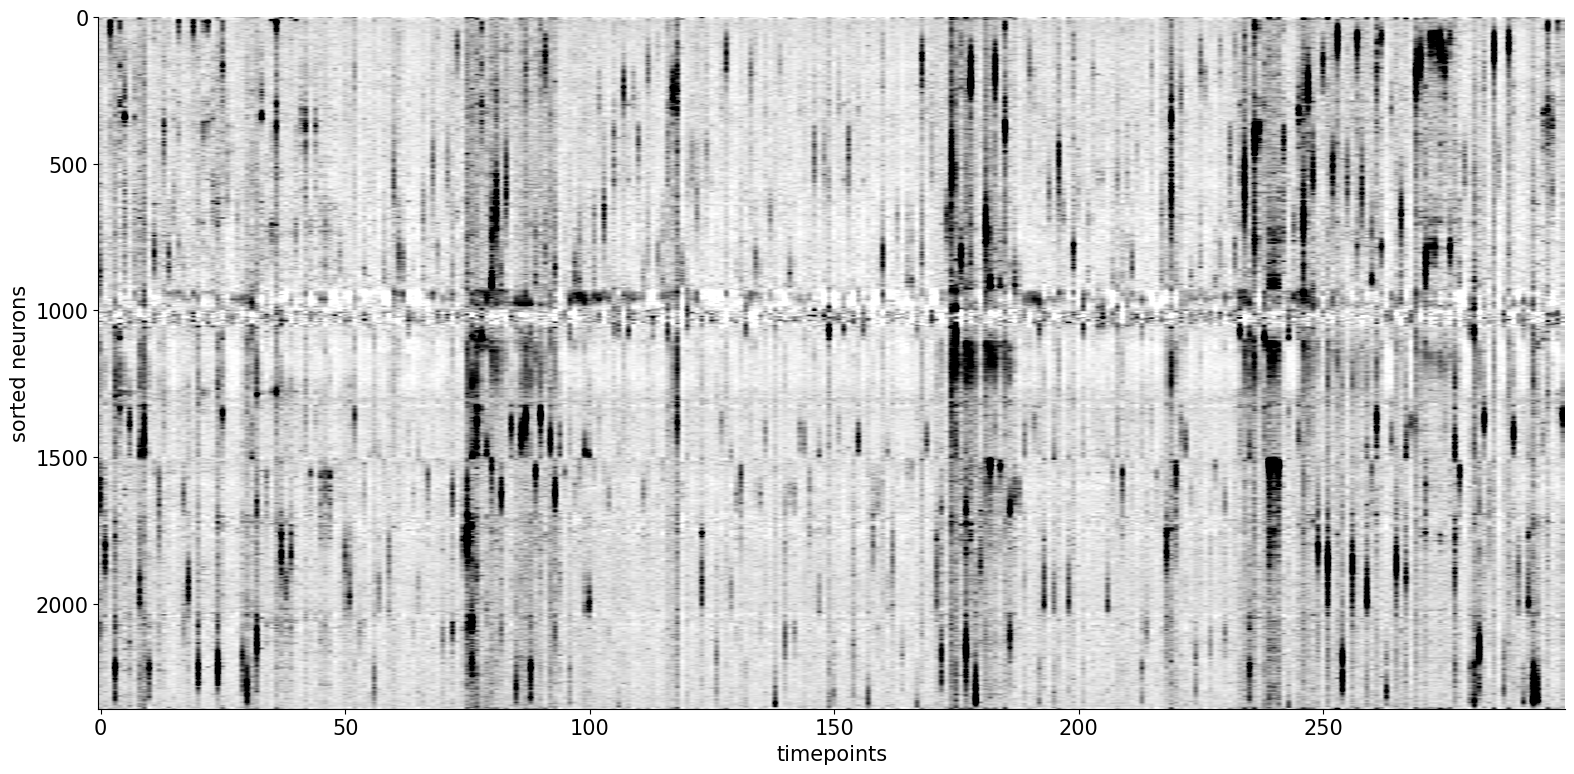

In [7]:
from umap import UMAP


print(sresp_der.shape)
corr = np.corrcoef(stim_der, sresp_der[0, :])
print(corr)

plt.scatter(stim_der, sresp_der[0, :])
#input line of correlation in the scatter plot
plt.plot([min(stim_der), max(stim_der)], [min(sresp_der[0, :]), max(sresp_der[0, :])], color='red')
corr, p_value = pearsonr(stim_der, sresp_der[0, :])
#set colour for each variable
plt.xlabel('acceleration')
plt.ylabel('stim_der')
plt.show()
print(corr)
print(p_value)

trange = np.arange(1000, 1200)

plt.plot(run[trange])
plt.xlabel('time')
plt.ylabel('speed')
plt.show()

plt.plot(acceleration[trange])
plt.xlabel('time')
plt.ylabel('acceleration')
plt.show()

# @title take PCA after preparing data by z-score

Z = zscore(dat['sresp'], axis=1)
Z = np.nan_to_num(Z)
X = PCA(n_components=200).fit_transform(Z)

ncomp = 1 # try 2, then try 3
xinit = 1 * zscore(X[:, :ncomp], axis=0)
embed = UMAP(n_components=ncomp, init=xinit, n_neighbors=20,
             metric='correlation', transform_seed=42).fit_transform(X)

embed = embed.flatten()
isort = np.argsort(embed)
RasterMap = uniform_filter1d(Z[isort, :], size=50, axis=0)
RasterMap = zscore(RasterMap[::10, :], axis=1)

plt.figure(figsize=(16, 8))
ax = plt.subplot(111)
trange = np.arange(1100, 1400)
plt.imshow(RasterMap[:, trange], vmax= 3, vmin=-1, aspect='auto', cmap='gray_r')
ax.set(xlabel='timepoints', ylabel='sorted neurons')
plt.show()

<ipython-input-8-facac8bc73e7>:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('jet')(xc)


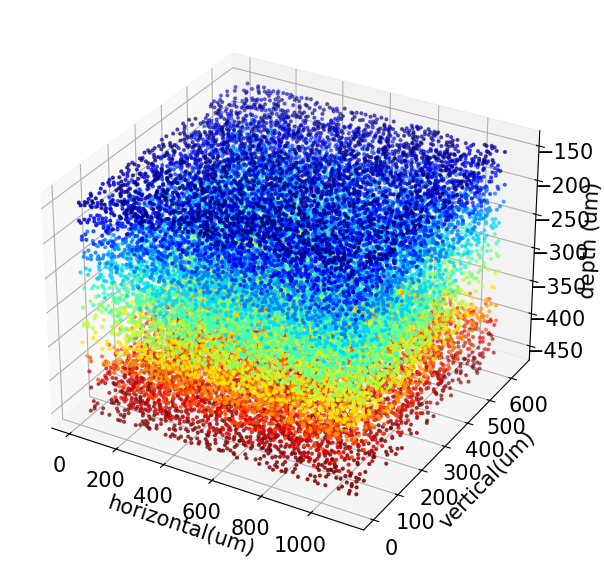

In [8]:
# @title plot the 3D positions of all neurons
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

x, y, z = dat['xyz']

zunq, iunq = np.unique(z, return_inverse=True)
xc = np.linspace(0.0, 1.0, len(zunq))
cmap = cm.get_cmap('jet')(xc)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[::-1], y[::-1], z[::-1], 'o', s=4, c=cmap[iunq])
ax.set(xlabel='horizontal(um)', ylabel='vertical(um)', zlabel='depth (um)')
plt.show()

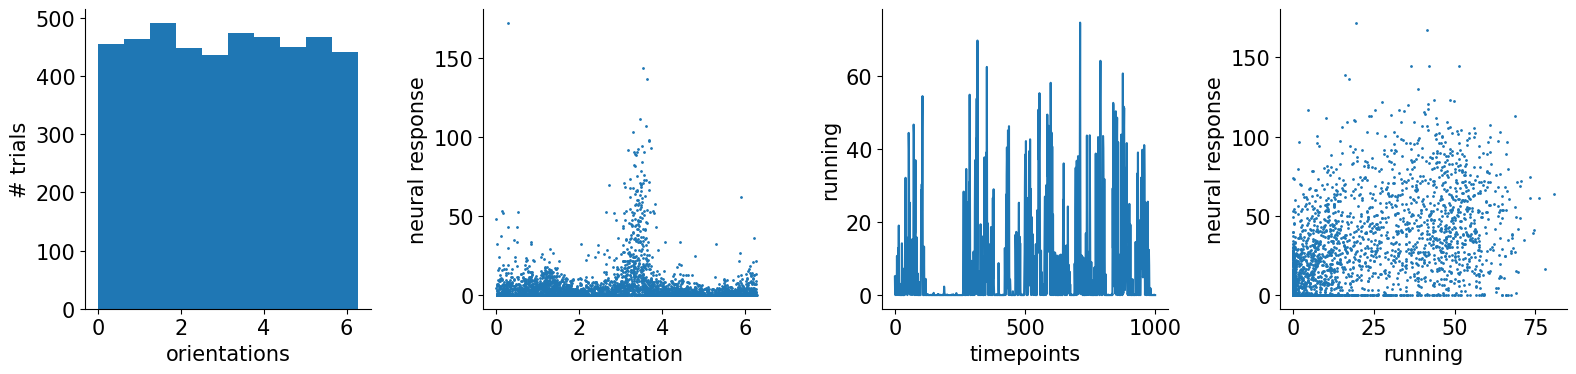

In [9]:
# @title Basic data properties using plot, hist and scatter
ax = plt.subplot(1, 5, 1)
plt.hist(dat['istim'])
ax.set(xlabel='orientations', ylabel='# trials')

ax = plt.subplot(1, 5, 2)
plt.scatter(dat['istim'], dat['sresp'][1000], s=1)
ax.set(xlabel='orientation', ylabel='neural response')

ax = plt.subplot(1, 5, 3)
plt.plot(dat['run'][:1000])
ax.set(xlabel='timepoints', ylabel='running')

ax = plt.subplot(1, 5, 4)
plt.scatter(dat['run'], dat['sresp'][20998], s=1)
ax.set(xlabel='running', ylabel='neural response')

plt.show()

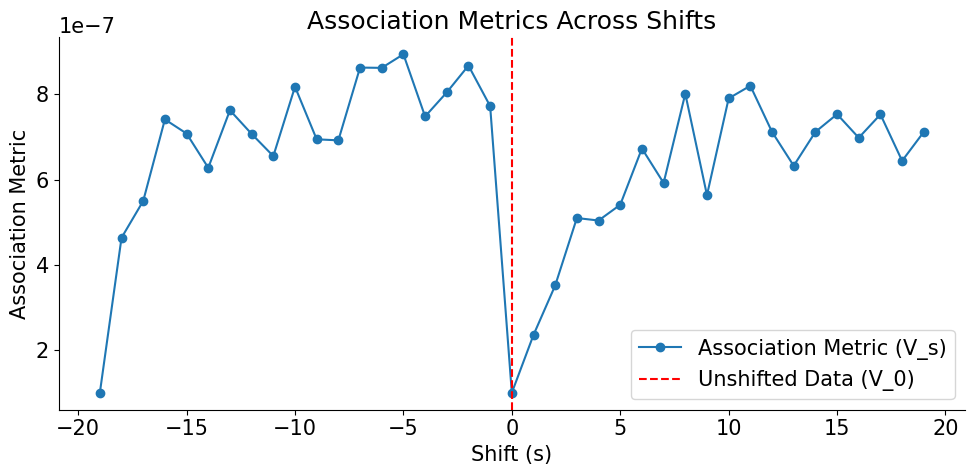

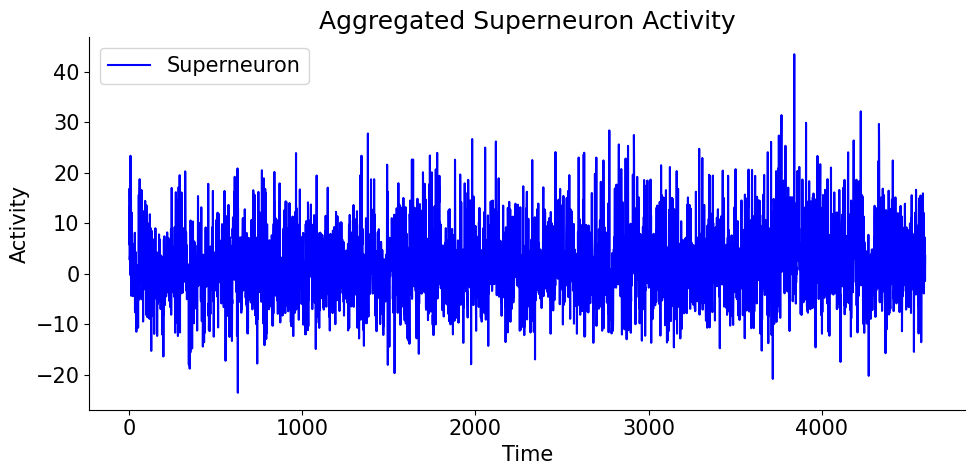

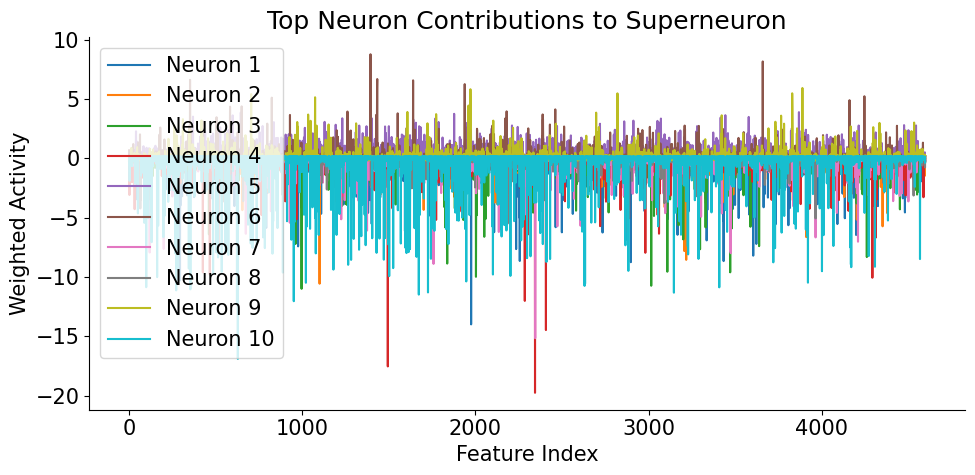

Superneuron shape: torch.Size([4598])
Weighted activity shape: torch.Size([4598, 100])
Selected sresp shape: torch.Size([4598, 100])
Superneuron weights shape: (1, 23589)


In [34]:
# @title Linear Shift - Superneurons

# Convert `run` and `istim` modality data to tensors
run_tensor = torch.tensor(dat['run'], dtype=torch.float32).view(-1, 1)
i_stim_tensor = torch.tensor(dat['istim'], dtype=torch.float32).view(-1, 1)
acceleration_tensor = torch.tensor(acceleration, dtype=torch.float32).view(-1, 1)

# Z-score the neural activity data
sresp_tensor = zscore(dat['sresp'])
sresp_tensor = torch.tensor(sresp_tensor, dtype=torch.float32).transpose(0, 1)

# --- Parameters ---
N = 19  # Maximum temporal shift to test
alpha = 0.05  # Significance level for rejecting the null hypothesis
metric = "mse"  # Metric to evaluate association: "mse" or "correlation"
top_k = 100  # Number of top neurons to include in the superneuron

# Align lengths of neural activity and modality data
T = min(len(sresp_tensor), len(run_tensor))
sresp = sresp_tensor[:T]
run_tensor = run_tensor[:T]

# Define the central segment of the modality (response variable)
y_segment = run_tensor[N:T-N]

# --- Linear Shift Analysis ---
V = []  # Stores association metrics across shifts

print("Calculating association metrics for shifted data...")
for s in range(-N, N + 1):
    # Shift neural activity (independent variable)
    if s < 0:
        x_shifted = sresp[-s:T-(N+s)]  # Shift left
    elif s > 0:
        x_shifted = sresp[N+s:T-s]  # Shift right
    else:
        x_shifted = sresp[N:T-N]  # No shift (unshifted data)

    # Ensure consistent length
    min_length = min(len(x_shifted), len(y_segment))
    x_shifted = x_shifted[:min_length]
    y_aligned = y_segment[:min_length]

    # Convert tensors to NumPy arrays for scikit-learn compatibility
    x_shifted_np = x_shifted.numpy()
    y_aligned_np = y_aligned.numpy()

    # Train a linear regression model
    model = LinearRegression().fit(x_shifted_np, y_aligned_np)
    y_pred = model.predict(x_shifted_np)

    # Compute the association metric
    if metric == "mse":
        V_s = np.mean((y_aligned_np - y_pred) ** 2)  # Mean Squared Error
    elif metric == "correlation":
        V_s = np.corrcoef(y_aligned_np.flatten(), y_pred.flatten())[0, 1]  # Correlation Coefficient
    else:
        raise ValueError("Invalid metric. Choose 'mse' or 'correlation'.")

    V.append(V_s)

# Perform the null hypothesis test
V_0 = V[N]  # Association for unshifted data
m = sum(1 for v in V if v <= V_0)  # Test statistic: count of shifts with stronger association
threshold = alpha * (2 * N + 1)

if m <= threshold:
    print(f"Null hypothesis rejected (m={m}, threshold={threshold:.2f}). Strong association detected for unshifted data.")
else:
    print(f"Null hypothesis not rejected (m={m}, threshold={threshold:.2f}). No strong association for unshifted data.")

# --- Extract Superneurons ---
superneuron_weights = model.coef_  # Linear regression weights
superneuron_indices = np.argsort(np.abs(superneuron_weights[0]))[::-1]  # Rank by absolute weight
top_neuron_indices = superneuron_indices[:top_k]  # Top k neurons by predictive power
top_neuron_indices = np.array(top_neuron_indices)  # Convert to NumPy array

# Extract the top k neurons and compute weighted activity
selected_sresp = sresp_tensor[:, top_neuron_indices].clone().contiguous()  # Ensure contiguous memory
weighted_activity = selected_sresp * torch.tensor(
    superneuron_weights[0, top_neuron_indices].copy(), dtype=torch.float32  # Ensure no negative strides
)

# Define the superneuron as the sum of weighted activity
superneuron = torch.sum(weighted_activity, axis=1)

# --- Plot Association Metrics ---
plt.figure(figsize=(10, 5))
shifts = np.arange(-N, N + 1)
plt.plot(shifts, V, marker="o", label="Association Metric (V_s)")
plt.axvline(x=0, color="red", linestyle="--", label="Unshifted Data (V_0)")
plt.title("Association Metrics Across Shifts")
plt.xlabel("Shift (s)")
plt.ylabel("Association Metric")
plt.legend()
plt.show()

# --- Plot Superneuron Activity ---
plt.figure(figsize=(10, 5))
plt.plot(superneuron.numpy(), label="Superneuron", color="blue")
plt.title("Aggregated Superneuron Activity")
plt.xlabel("Time")
plt.ylabel("Activity")
plt.legend()
plt.show()

# --- Plot Top Neuron Weights ---
plt.figure(figsize=(10, 5))
for i, weight in enumerate(weighted_activity[:, :10].T):  # Plot top 10 neurons
    plt.plot(weight.numpy(), label=f"Neuron {i+1}")
plt.title("Top Neuron Contributions to Superneuron")
plt.xlabel("Feature Index")
plt.ylabel("Weighted Activity")
plt.legend()
plt.show()

# --- Debugging Info ---
print("Superneuron shape:", superneuron.shape)
print("Weighted activity shape:", weighted_activity.shape)
print("Selected sresp shape:", selected_sresp.shape)
print("Superneuron weights shape:", superneuron_weights.shape)


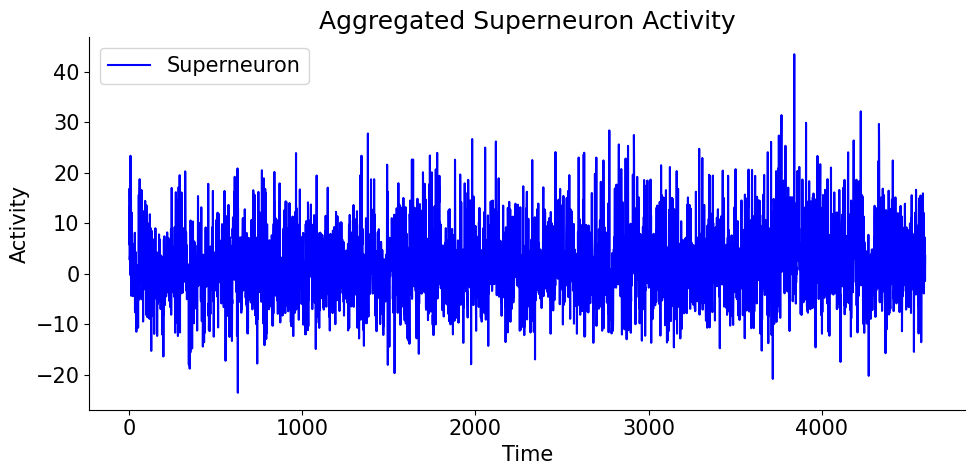

sresp_tensor shape: torch.Size([4598, 23589])
top_neuron_indices shape: (100,)
superneuron_weights shape: (1, 23589)
selected_sresp shape: torch.Size([4598, 100])
weighted_activity shape: torch.Size([4598, 100])
superneuron shape: torch.Size([4598])
Calculating association metrics for shifted superneuron activity...
Null hypothesis not rejected (m=28). No strong association for unshifted superneuron activity.


In [29]:
# @title Superneurons

# Rank neurons by absolute value of their weights
superneuron_indices = np.argsort(np.abs(superneuron_weights[0]))[::-1]  # Descending order
top_k = 100  # Number of top neurons to include in the superneuron
top_neuron_indices = superneuron_indices[:top_k]  # Indices of top predictive neurons

# Ensure sresp_tensor and superneuron_weights are properly aligned
sresp_tensor = sresp_tensor.contiguous()  # Make sure sresp_tensor is contiguous
superneuron_weights = np.array(superneuron_weights)  # Convert weights to a NumPy array if necessary

# Select the top neurons and ensure no negative strides
top_neuron_indices = np.array(top_neuron_indices)  # Ensure indices are in a valid format

# Explicitly copy the selection to avoid negative strides
selected_sresp = sresp_tensor[:, top_neuron_indices].clone()

# Weight neural activity by regression coefficients
weighted_activity = selected_sresp * torch.tensor(
    superneuron_weights[0, top_neuron_indices], dtype=torch.float32
)

# Define the superneuron as the sum of weighted activity
superneuron = torch.sum(weighted_activity, axis=1)  # Shape: (T,)

# Plot the superneuron activity over time
plt.figure(figsize=(10, 5))
plt.plot(superneuron.numpy(), label="Superneuron", color="blue")
plt.title("Aggregated Superneuron Activity")
plt.xlabel("Time")
plt.ylabel("Activity")
plt.legend()
plt.show()

print("sresp_tensor shape:", sresp_tensor.shape)
print("top_neuron_indices shape:", top_neuron_indices.shape)
print("superneuron_weights shape:", superneuron_weights.shape)
print("selected_sresp shape:", selected_sresp.shape)
print("weighted_activity shape:", weighted_activity.shape)
print("superneuron shape:", superneuron.shape)




In [11]:
# # @title take PCA after preparing data by z-score

# Z = zscore(dat['sresp'], axis=1)
# X = PCA(n_components=200).fit_transform(Z.T)

In [12]:
# # @title plot PCs as function of stimulus orientation
# for j in range(5):
#   ax = plt.subplot(1, 5, j + 1)
#   plt.scatter(dat['istim'], X[:, j], s=1)
#   ax.set(xlabel='orientation', ylabel='PC%d'%j)
# plt.show()

In [13]:
# # @title run a manifold embedding algorithm (UMAP) in two or three dimensions.

# ncomp = 3  # try 2, then try 3
# xinit = 3 * zscore(X[:, :ncomp], axis=0)
# embed = UMAP(n_components=ncomp, init=xinit, n_neighbors=25,
#              metric='correlation', transform_seed=42).fit_transform(X)

In [14]:
# plt.figure(figsize=(8,8))
# for i in range(ncomp):
#   for j in range(ncomp):
#     plt.subplot(ncomp,ncomp, j + ncomp*i + 1)
#     if i == j:
#       plt.scatter(dat['istim'], embed[:, i], s=1)
#     else:
#       plt.scatter(embed[:, j], embed[:, i], s=1, c=dat['istim'], cmap='hsv')
# plt.show()

In [15]:
# plt.figure(figsize=(8, 4))
# plt.subplot(1, 2, 1)
# plt.scatter(embed[:, 0], embed[:, 2], s=4, c=dat['istim'], cmap='hsv')
# plt.title('colored by stimulus orientation')

# plt.subplot(1, 2, 2)
# plt.scatter(embed[:, 0], embed[:, 2], s=4, c=dat['run'], vmin=0, vmax=10)
# plt.title('colored by running speed')
# plt.show()

In [16]:
# @title PCA

def plot_variance_explained(variance_explained):
  """
  Plots eigenvalues.

  Args:
    variance_explained (numpy array of floats) : Vector of variance explained
                                                 for each PC

  Returns:
    Nothing.

  """

  plt.figure()
  plt.plot(np.arange(1, len(variance_explained) + 1), variance_explained,
           '--k')
  plt.xlabel('Number of components')
  plt.ylabel('Variance explained')
  plt.show()

def plot_eigenvalues(evals, xlimit=False):
  """
  Plots eigenvalues.

  Args:
     (numpy array of floats) : Vector of eigenvalues
     (boolean) : enable plt.show()
  Returns:
    Nothing.

  """

  plt.figure()
  plt.plot(np.arange(1, len(evals) + 1), evals, 'o-k')
  plt.xlabel('Component')
  plt.ylabel('Eigenvalue')
  plt.title('Scree plot')
  if xlimit:
    plt.xlim([0, 100])  # limit x-axis up to 100 for zooming
  plt.show()

def sort_evals_descending(evals, evectors):
  """
  Sorts eigenvalues and eigenvectors in decreasing order. Also aligns first two
  eigenvectors to be in first two quadrants (if 2D).

  Args:
    evals (numpy array of floats)    :   Vector of eigenvalues
    evectors (numpy array of floats) :   Corresponding matrix of eigenvectors
                                         each column corresponds to a different
                                         eigenvalue

  Returns:
    (numpy array of floats)          : Vector of eigenvalues after sorting
    (numpy array of floats)          : Matrix of eigenvectors after sorting
  """

  index = np.flip(np.argsort(evals))
  evals = evals[index]
  evectors = evectors[:, index]
  if evals.shape[0] == 2:
    if np.arccos(np.matmul(evectors[:, 0],
                           1 / np.sqrt(2) * np.array([1, 1]))) > np.pi / 2:
      evectors[:, 0] = -evectors[:, 0]
    if np.arccos(np.matmul(evectors[:, 1],
                           1 / np.sqrt(2)*np.array([-1, 1]))) > np.pi / 2:
      evectors[:, 1] = -evectors[:, 1]

  return evals, evectors

def get_sample_cov_matrix(X):
  """
  Returns the sample covariance matrix of data X.

  Args:
    X (numpy array of floats) : Data matrix each column corresponds to a
                                different random variable

  Returns:
    (numpy array of floats)   : Covariance matrix
"""

  X = X - np.mean(X, 0)
  cov_matrix = 1 / X.shape[0] * np.matmul(X.T, X)
  return cov_matrix

def pca(X):
    """
    Performs PCA on multivariate data. Eigenvalues are sorted in decreasing order.

    Args:
        X (numpy array of floats): Data matrix where each column is a different random variable.

    Returns:
        (numpy array of floats): Data projected onto the new basis (scores).
        (numpy array of floats): Corresponding matrix of eigenvectors (loadings).
        (numpy array of floats): Vector of eigenvalues.
    """
    # Centering the data
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean

    # Computing the covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)

    # Eigen decomposition
    evals, evectors = np.linalg.eigh(cov_matrix)
    evals, evectors = sort_evals_descending(evals, evectors)

    # Projecting the data onto the new basis
    scores = np.dot(X_centered, evectors)

    return scores, evectors, evals

def sort_evals_descending(evals, evectors):
    """
    Sorts eigenvalues and eigenvectors in decreasing order.

    Args:
        evals (numpy array of floats): Vector of eigenvalues.
        evectors (numpy array of floats): Corresponding matrix of eigenvectors, each column is an eigenvector.

    Returns:
        (numpy array of floats): Eigenvalues in descending order.
        (numpy array of floats): Eigenvectors in descending order.
    """
    idx = np.argsort(evals)[::-1]
    evals_sorted = evals[idx]
    evectors_sorted = evectors[:, idx]
    return evals_sorted, evectors_sorted

def get_variance_explained(evals):
  """
  Calculates variance explained from the eigenvalues.

  Args:
    evals (numpy array of floats) : Vector of eigenvalues

  Returns:
    (numpy array of floats)       : Vector of variance explained

  """

  # Cumulatively sum the eigenvalues
  csum = np.cumsum(evals)

  # Normalize by the sum of eigenvalues
  variance_explained = csum / np.sum(evals)

  return variance_explained


def reconstruct_data(score, evectors, X_mean, K):
    """
    Reconstruct the data based on the top K components.
    """
    # Ensure all inputs are numpy arrays and have correct dimensions
    score = np.atleast_2d(score)
    evectors = np.atleast_2d(evectors)
    X_mean = np.atleast_1d(X_mean)

    # Debugging shapes
    print("Score shape:", score.shape)
    print("Evectors shape:", evectors.shape)
    print("X_mean shape:", X_mean.shape)

    if K > evectors.shape[1]:
        raise ValueError(f"K is too large. Maximum allowable is {evectors.shape[1]}")

    # Reconstruct the data from the score and eigenvectors, and then add back the mean
    X_reconstructed = np.matmul(score[:, :K], evectors[:, :K].T) + X_mean

    return X_reconstructed


# K = 784  # data dimensions

# # Reconstruct the data based on all components
# X_mean = np.mean(X, 0)
# X_reconstructed = reconstruct_data(score, evectors, X_mean, K)

# # Plot the data and reconstruction
# plot_MNIST_reconstruction(X, X_reconstructed, K)

def plot_data_comparison(original_data, reconstructed_data):
    """
    Plots a comparison of the original data and reconstructed data.

    Args:
        original_data (numpy array): The original data matrix.
        reconstructed_data (numpy array): The PCA reconstructed data matrix.
    """
    plt.figure(figsize=(12, 6))

    # Plotting the original data
    plt.subplot(1, 2, 1)
    plt.scatter(original_data[:, 0], original_data[:, 1], c='blue', alpha=0.5, label='Original Data')
    plt.title('Original Data')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()

    # Plotting the reconstructed data
    plt.subplot(1, 2, 2)
    plt.scatter(reconstructed_data[:, 0], reconstructed_data[:, 1], c='red', alpha=0.5, label='Reconstructed Data')
    plt.title('Reconstructed Data')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()

    plt.show()

# Example usage:
# Assuming 'activated_xyz' is your original dataset and 'reconstructed_data' is what you obtained from PCA

def calculate_mse(original_data, reconstructed_data):
    """
    Calculates the mean squared error between the original data and the reconstructed data.

    Args:
        original_data (numpy array): The original data matrix.
        reconstructed_data (numpy array): The PCA reconstructed data matrix.

    Returns:
        float: The mean squared error.
    """
    # Ensure both datasets have the same shape
    if original_data.shape != reconstructed_data.shape:
        raise ValueError("Original and reconstructed data must have the same dimensions.")

    # Compute MSE
    mse = np.mean((original_data - reconstructed_data) ** 2) / len(activated_xyz)
    return mse


Shape of pupil_area_tensor: torch.Size([4598, 1])
Shape of sresp_tensor: torch.Size([4598, 23589])
Shape of i_stim_tensor: torch.Size([4598, 1])
(4598, 23590)
Score shape: (4598, 4598)
Evectors shape: (4598, 23590)
Evals shape: (4598,)
X_mean shape: (23590,)
Number of components to explain 95% variance: 2177


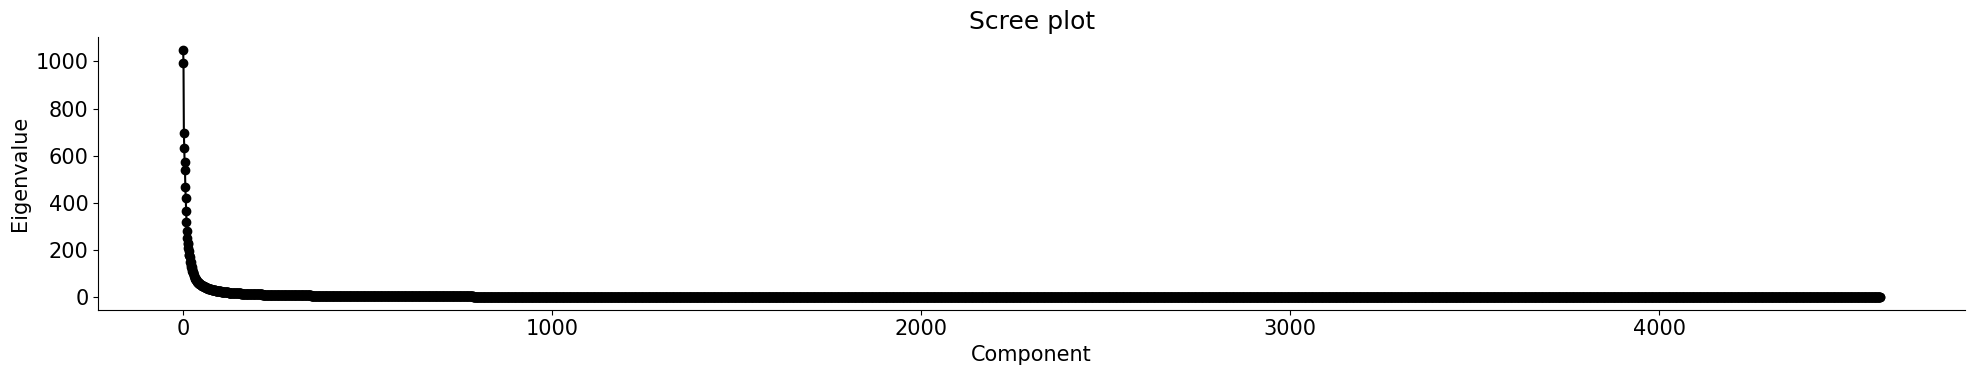

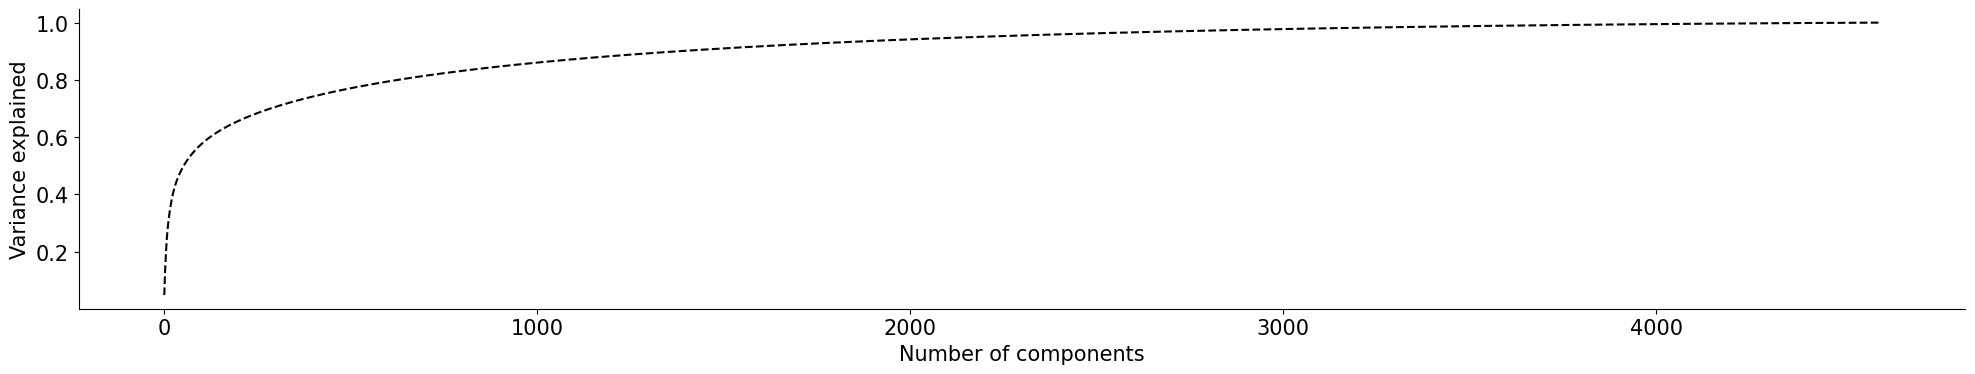

Reconstructed shape: (4598, 23590)


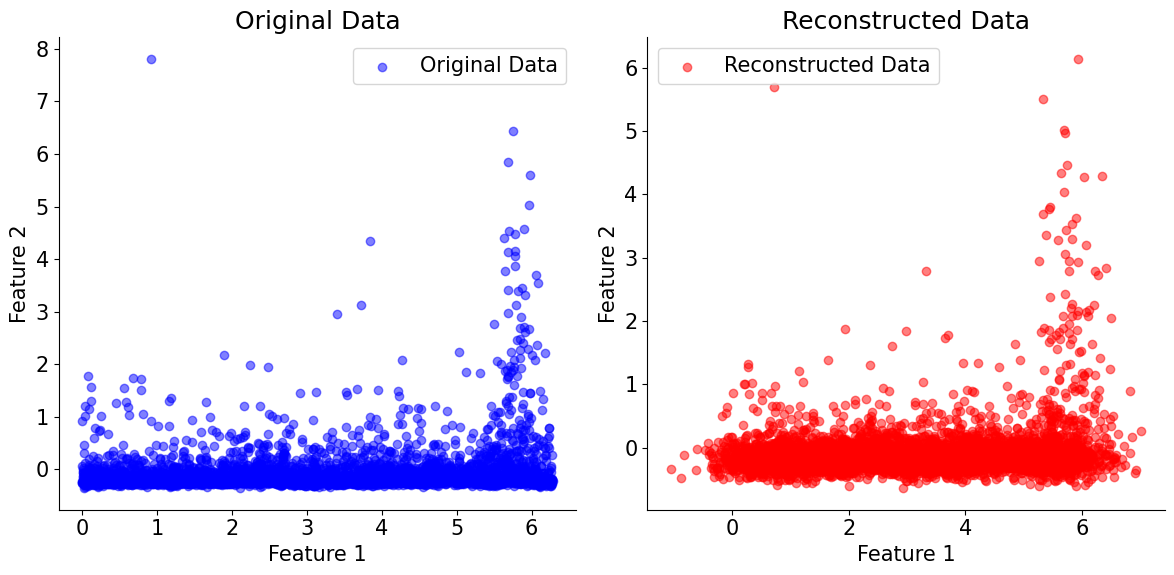

Mean Squared Error (MSE): 9.959795329559363e-06


In [17]:
# @title PCA run

run_tensor = torch.tensor(dat['run'], dtype=torch.float32).view(-1, 1)
# sresp_tensor = torch.tensor(dat['sresp'], dtype=torch.float32).transpose(0, 1)
i_stim_tensor = torch.tensor(dat['istim'], dtype=torch.float32).view(-1, 1)

# Z-score the data
sresp_tensor = zscore(dat['sresp'])
sresp_tensor = torch.tensor(sresp_tensor, dtype=torch.float32).transpose(0, 1)

# Checking the shape to ensure correctness
print("Shape of pupil_area_tensor:", run_tensor.shape)  # Expected [7018, 1]
print("Shape of sresp_tensor:", sresp_tensor.shape)           # Expected [7018, 11983]
print("Shape of i_stim_tensor:", i_stim_tensor.shape)  # Expected [7018, 1]

dataset = TensorDataset(i_stim_tensor, sresp_tensor)
dataset_np = np.concatenate((i_stim_tensor.numpy(), sresp_tensor.numpy()), axis=1)
print(dataset_np.shape)# Let's recalculate 'X_mean' correctly

X_mean = np.mean(dataset_np, axis=0)  # Mean over samples, not features

# Assuming PCA function and other setup
pca = PCA()
score = pca.fit_transform(dataset_np)  # Fit and transform the data
evectors = pca.components_
evals = pca.explained_variance_

# Check shapes after PCA
print("Score shape:", score.shape)
print("Evectors shape:", evectors.shape)
print("Evals shape:", evals.shape)
print("X_mean shape:", X_mean.shape)

# Calculate the variance explained
variance_explained = np.cumsum(pca.explained_variance_ratio_)
K = np.argmax(variance_explained >= 0.95)  # Index where cumulative variance >= 95%, add 1 because index starts at 0
print(f"Number of components to explain 95% variance: {K}")

plot_eigenvalues(evals)
plot_variance_explained(variance_explained)
# Reconstruct data using K components
X_reconstructed = np.dot(score[:, :K], evectors[:K, :]) + X_mean  # Reconstruct from first K components

# Ensure shapes are consistent
print("Reconstructed shape:", X_reconstructed.shape)

# Function to plot data comparison (assuming you have a visualization setup)
plot_data_comparison(dataset_np, X_reconstructed)

input_shape = dataset[0][0].shape[0]

# Calculate MSE (Mean Squared Error)
mse_value = np.mean((dataset_np - X_reconstructed)**2) * input_shape
print("Mean Squared Error (MSE):", mse_value / len(dataset_np))


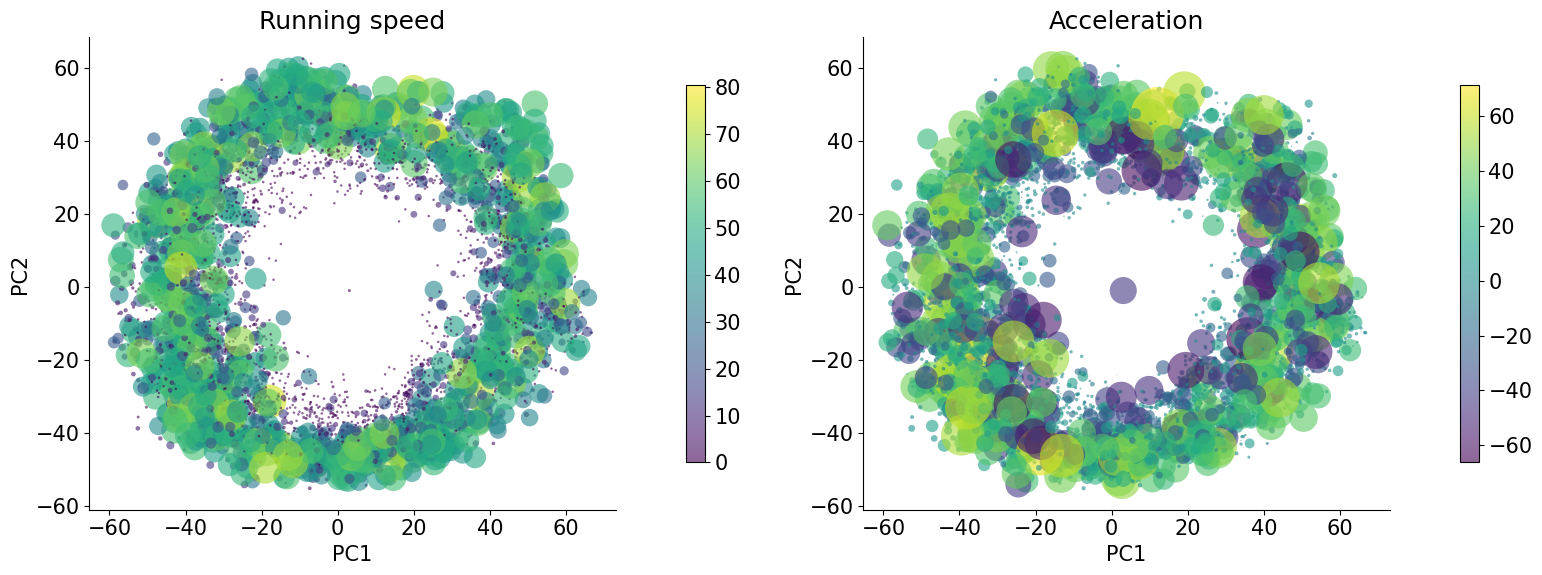

In [18]:
# @title PCA running and acceleration
# Neural data
num_components = K
Zsresp = zscore(dat['sresp'].T, axis=1)
Zsresp = np.nan_to_num(Zsresp)
X = PCA(n_components=num_components).fit_transform(Zsresp)

fig = plt.figure(figsize=(16, 6))
ax = fig.add_subplot(121)

sc = ax.scatter(score[:,0], score[:,1],
                c=run, alpha=0.6, edgecolor='none',
                s=(0.3*(run+6))**2,
                cmap="viridis")
ax.set_title("Running speed")
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(sc, pad=0.1, shrink=0.8)

ax = fig.add_subplot(122)
sc = ax.scatter(score[:,0], score[:,1],
                c=(acceleration), alpha=0.6, edgecolor='none',
                s=(0.5*(acceleration+5))**2,
                cmap="viridis")
ax.set_title("Acceleration")
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(sc, pad=0.1, shrink=0.8)
#plt.savefig("pca_speed_acc.png")
plt.show()

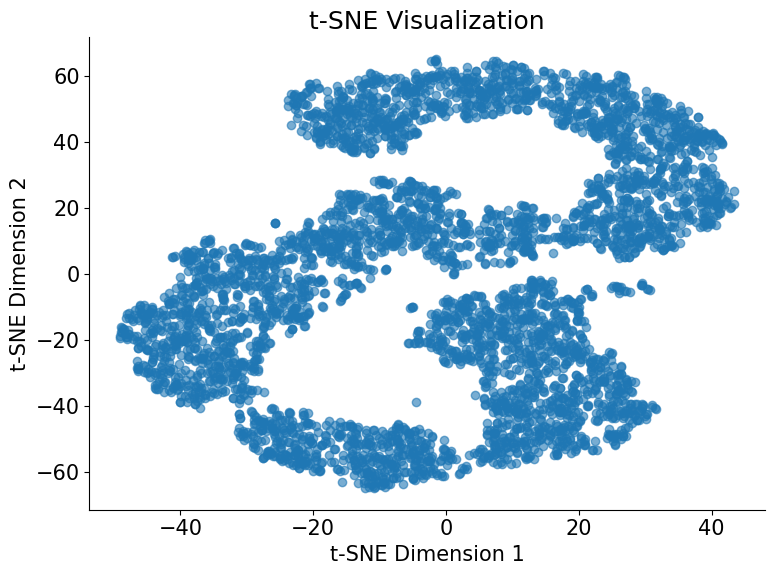

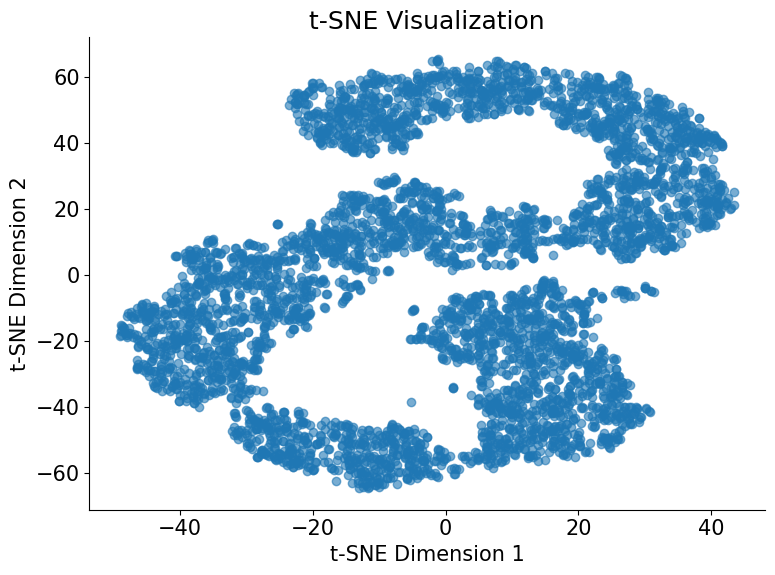

In [ ]:
# @title t-SNE


# mean_activity_reshaped = mean_activity[:, np.newaxis]  # This should create a [neurons, 1] array


# print("Shape of xyz:", xyz.shape)  # Expected output: (number of neurons, 3)
# print("Shape of mean_activity_reshaped:", mean_activity_reshaped.shape)  # Expected output: (number of neurons, 1)


# try:
#     combined_data = np.concatenate((xyz, mean_activity_reshaped), axis=1)
#     print("Combined data shape:", combined_data.shape)  # Expected output: (number of neurons, 4)
# except ValueError as e:
#     print("Error in concatenation:", e)



tsne_model = TSNE(n_components=2, perplexity=50, random_state=2020)
tsne_data = tsne_model.fit_transform(dataset_np)


def visualize_tsne(tsne_results):
    plt.figure(figsize=(8, 6))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], alpha=0.6)
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.title('t-SNE Visualization')
    plt.show()

visualize_tsne(tsne_data)


tsne_active = tsne_model.fit_transform(sresp_tensor.numpy())
visualize_tsne(tsne_active)

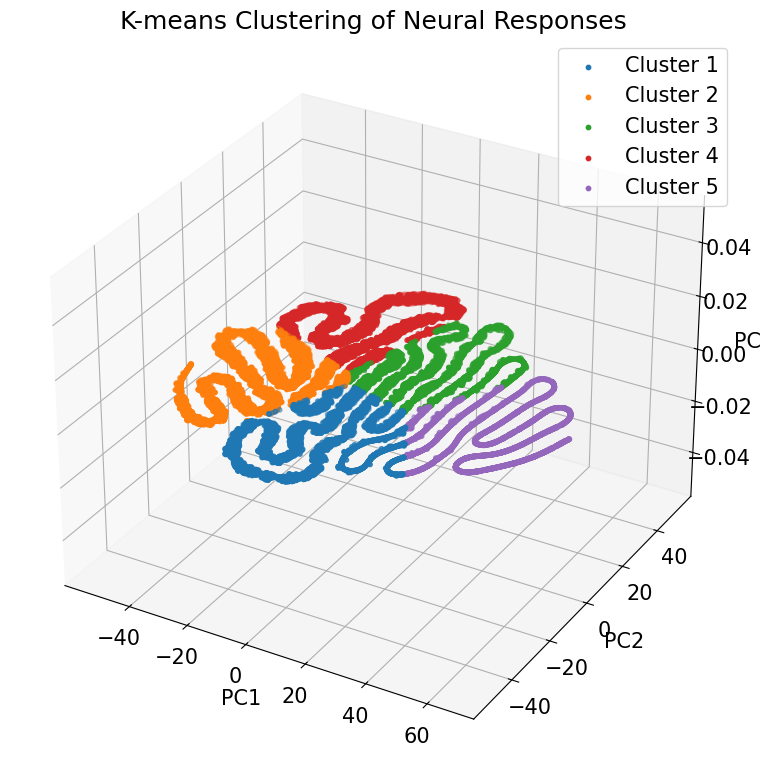

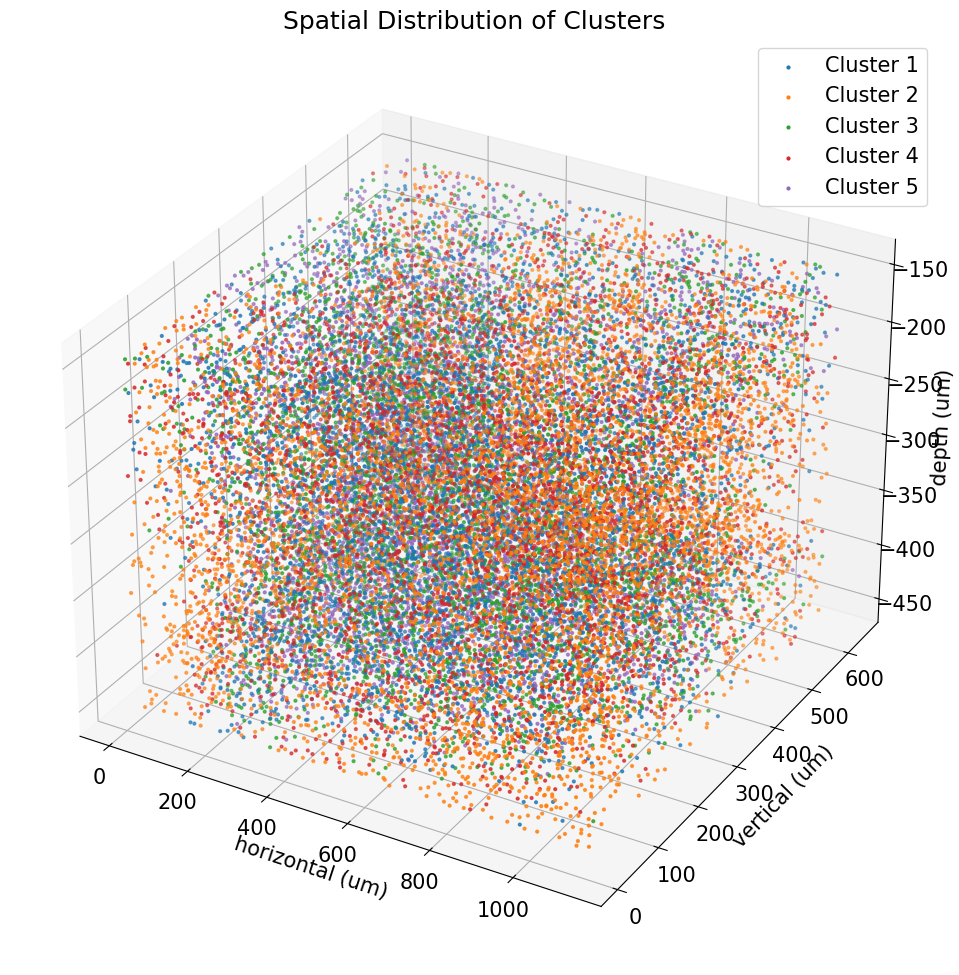

In [ ]:
# @title K-means


# Load data (assuming 'dat' has been loaded as per previous discussion)
neural_responses = dat['sresp']  # Neurons by stimuli
stimuli = dat['istim']
running_speed = dat['run']

# Feature Engineering
mean_responses = np.mean(neural_responses, axis=1)  # Average response of each neuron across stimuli
var_responses = np.var(neural_responses, axis=1)  # Variability of each neuron's response across stimuli

# Average the running speed across trials to match the length of mean_responses and var_responses
mean_running_speed = np.mean(running_speed)  # Single value across all trials
mean_running_speeds = np.full(mean_responses.shape, mean_running_speed)  # Create an array of the same length

mean_acceleration = np.mean(acceleration)
mean_accelerations = np.full(mean_responses.shape, mean_acceleration)

# Combine features: mean response, variance, averaged running speed
features = np.column_stack((mean_responses, var_responses, mean_accelerations))

# Dimensionality Reduction (optional but recommended for visualization)
# pca = PCA(n_components=3)  # Reduce to 3 dimensions for easier visualization
# features_pca = pca.fit_transform(features)

tsne_model = TSNE(n_components=3, perplexity=50, random_state=2020)
features_tsne = tsne_model.fit_transform(features)

# Apply K-means clustering
n_clusters = 5  # This can be determined via the Elbow method or Silhouette analysis
kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(features_tsne)
labels = kmeans.labels_

# 3D Visualization of Clusters
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(n_clusters):
    cluster_points = features_tsne[labels == cluster]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], label=f'Cluster {cluster+1}', s=10)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.title('K-means Clustering of Neural Responses')
plt.show()

# Analysis: Map Clusters back to Neuron Locations
neuron_locations = dat['xyz']
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(n_clusters):
    cluster_locs = neuron_locations[:, labels == cluster]
    ax.scatter(cluster_locs[0, :], cluster_locs[1, :], cluster_locs[2, :], label=f'Cluster {cluster+1}', s=4)

ax.set_xlabel('horizontal (um)')
ax.set_ylabel('vertical (um)')
ax.set_zlabel('depth (um)')
ax.legend()
plt.title('Spatial Distribution of Clusters')
plt.show()

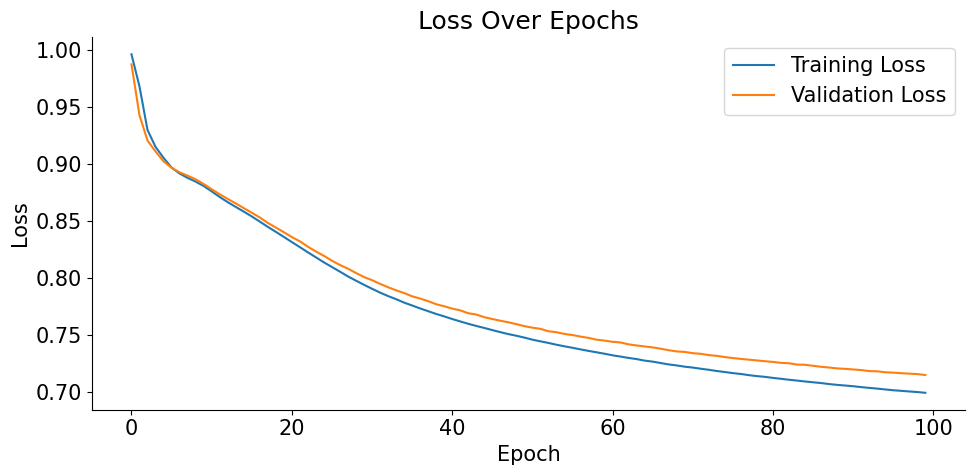

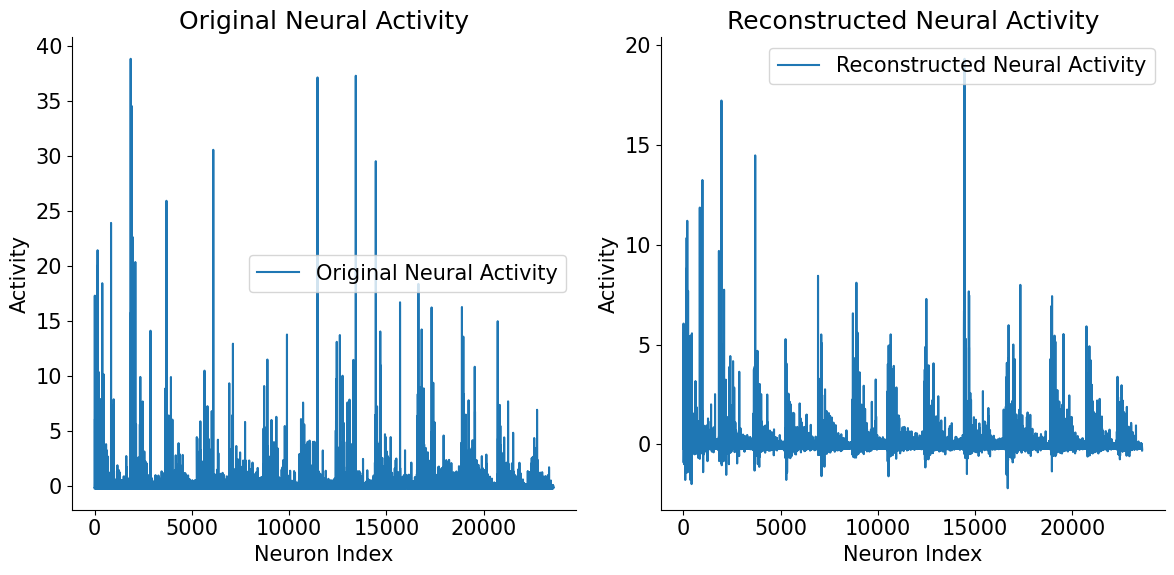

Average Correlation: 0.5293
Overall MSE: 0.7180
R²: 0.2820


In [ ]:
# @title Deep Non-Linear Autoencoder


# Assuming dat is your data dictionary containing modalities and neural activity
i_stim = dat['istim']
sresp = dat['sresp']
acceleration = acceleration
run = dat['run']

# Ensure the number of samples match
num_samples = min(i_stim.shape[0], run.shape[0], sresp.shape[1])

i_stim = i_stim[:num_samples]
run = run[:num_samples]
acceleration = acceleration[:num_samples]
sresp = sresp[:, :num_samples]

# Handle NaN values before normalization
i_stim = handle_na(i_stim)
run = handle_na(run)
acceleration = handle_na(acceleration)
sresp = handle_na(sresp)

# Normalize the neural activity data
sresp_zscored = zscore(sresp)
sresp_tensor_zscored = torch.tensor(sresp_zscored, dtype=torch.float32).transpose(0, 1)

# Normalize i_stim and run
i_stim = zscore(i_stim)
run = zscore(run)
acceleration = zscore(acceleration)

# Ensure consistent float32 tensors
i_stim_tensor = torch.tensor(i_stim, dtype=torch.float32).view(-1, 1)
run_tensor = torch.tensor(run, dtype=torch.float32)
acceleration_tensor = torch.tensor(acceleration, dtype=torch.float32)
sresp_tensor_zscored = sresp_tensor_zscored.float()

# Concatenate modalities as inputs
input_tensor = torch.cat((i_stim_tensor, run_tensor, acceleration_tensor), dim=1).float()

# Ensure TensorDataset has input (modality) and output (neural activity)
dataset = TensorDataset(input_tensor, sresp_tensor_zscored)

# Split dataset into train, validation, and test sets
train_data, temp_data = train_test_split(dataset, test_size=0.4, random_state=42)
validation_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Create DataLoaders for efficient data handling
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=100, shuffle=False)
test_loader = DataLoader(test_data, batch_size=100, shuffle=False)

# Define the Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_sizes[1], hidden_sizes[2]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[2], output_size)
        )

    def forward(self, x, return_activations=False):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        if return_activations:
            return reconstructed, encoded
        return reconstructed

# Initialize model with corrected sizes
input_size = input_tensor.shape[1]  # Number of input features
hidden_sizes = [150, 300, 600]      # Hidden layer sizes
output_size = sresp_tensor_zscored.shape[1]  # Number of neurons in the output
model = Autoencoder(input_size, hidden_sizes, output_size).float()

# Move model to appropriate device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = nn.MSELoss()

# Debug: Print model and input tensor dtypes
print(f"Model parameters dtype: {[p.dtype for p in model.parameters()]}")
print(f"Input tensor dtype: {input_tensor.dtype}")

# Train the model
num_epochs = 100
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    print(f'Epoch {epoch+1}, Training Loss: {avg_train_loss:.4f}')

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in validation_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = loss_function(outputs, targets)
            val_loss += loss.item() * inputs.size(0)

    avg_val_loss = val_loss / len(validation_loader.dataset)
    val_losses.append(avg_val_loss)
    print(f'Epoch {epoch+1}, Validation Loss: {avg_val_loss:.4f}')

# Plot the training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Evaluate the model on the test set
model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device).float(), targets.to(device).float()
        outputs = model(inputs)
        break  # Use only the first batch for visualization

# Convert tensors to numpy for plotting and evaluation
inputs_np = inputs.cpu().numpy()
targets_np = targets.cpu().numpy()
outputs_np = outputs.cpu().numpy()

# Plot the original and reconstructed neural activity
plt.figure(figsize=(12, 6))

# Original Neural Activity
plt.subplot(1, 2, 1)
plt.plot(targets_np[0], label='Original Neural Activity')
plt.title('Original Neural Activity')
plt.xlabel('Neuron Index')
plt.ylabel('Activity')
plt.legend()

# Reconstructed Neural Activity
plt.subplot(1, 2, 2)
plt.plot(outputs_np[0], label='Reconstructed Neural Activity')
plt.title('Reconstructed Neural Activity')
plt.xlabel('Neuron Index')
plt.ylabel('Activity')
plt.legend()

plt.show()

# Compute evaluation metrics
correlations = [pearsonr(targets_np[i], outputs_np[i])[0] for i in range(targets_np.shape[0])]
average_correlation = np.mean(correlations)
overall_mse = np.mean((targets_np - outputs_np) ** 2)
r2 = r2_score(targets_np.flatten(), outputs_np.flatten())

print(f'Average Correlation: {average_correlation:.4f}')
print(f'Overall MSE: {overall_mse:.4f}')
print(f'R²: {r2:.4f}')


Training on Stimulus Orientation...
Epoch [1/100], Train Loss: 0.7981, Val Loss: 0.4155
Epoch [2/100], Train Loss: 0.3383, Val Loss: 0.2957
Epoch [3/100], Train Loss: 0.2600, Val Loss: 0.2307
Epoch [4/100], Train Loss: 0.1981, Val Loss: 0.2379
Epoch [5/100], Train Loss: 0.1641, Val Loss: 0.1865
Epoch [6/100], Train Loss: 0.1402, Val Loss: 0.2058
Epoch [7/100], Train Loss: 0.1262, Val Loss: 0.1938
Epoch [8/100], Train Loss: 0.1141, Val Loss: 0.1707
Epoch [9/100], Train Loss: 0.1067, Val Loss: 0.1728
Epoch [10/100], Train Loss: 0.1047, Val Loss: 0.1750
Epoch [11/100], Train Loss: 0.0997, Val Loss: 0.1743
Epoch [12/100], Train Loss: 0.0959, Val Loss: 0.1770
Epoch [13/100], Train Loss: 0.0937, Val Loss: 0.1810
Epoch [14/100], Train Loss: 0.0915, Val Loss: 0.1724
Epoch [15/100], Train Loss: 0.0901, Val Loss: 0.1702
Epoch [16/100], Train Loss: 0.0895, Val Loss: 0.1746
Epoch [17/100], Train Loss: 0.0842, Val Loss: 0.1696
Epoch [18/100], Train Loss: 0.0860, Val Loss: 0.1876
Epoch [19/100], Tra

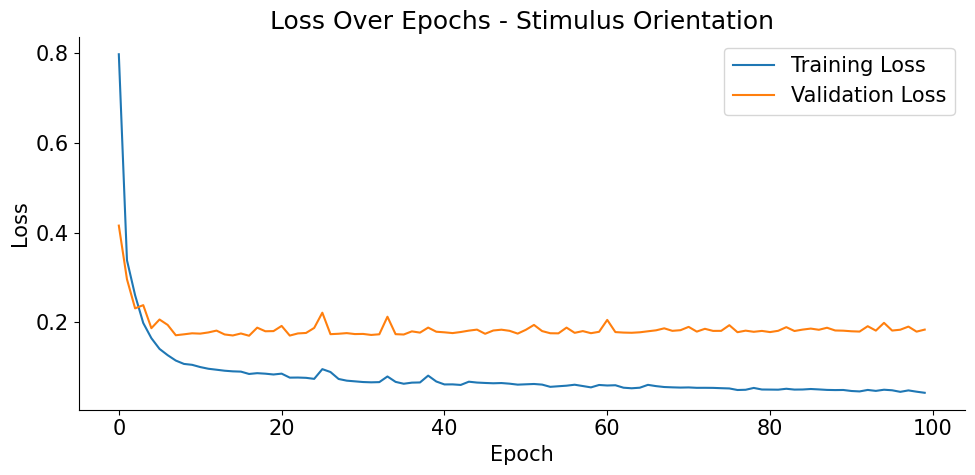

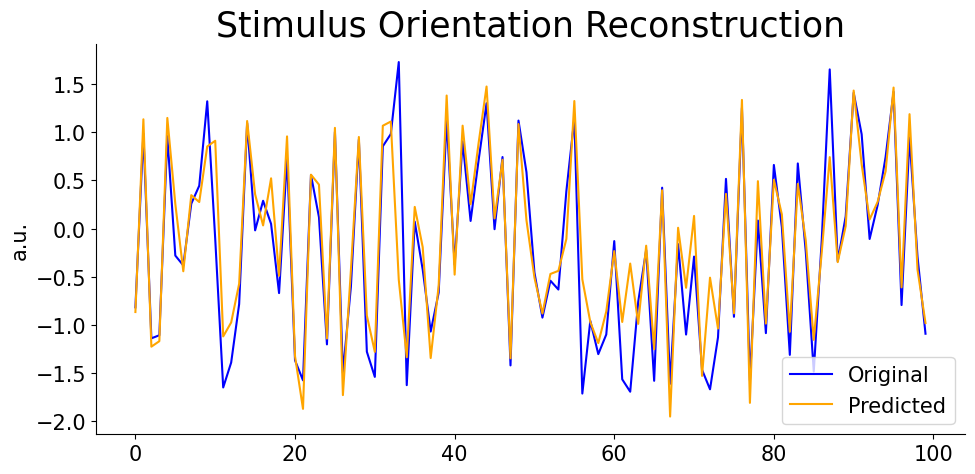

Correlation for Stimulus Orientation: 0.9104
MSE for Stimulus Orientation: 0.1675
R^2 for Stimulus Orientation: 0.8289


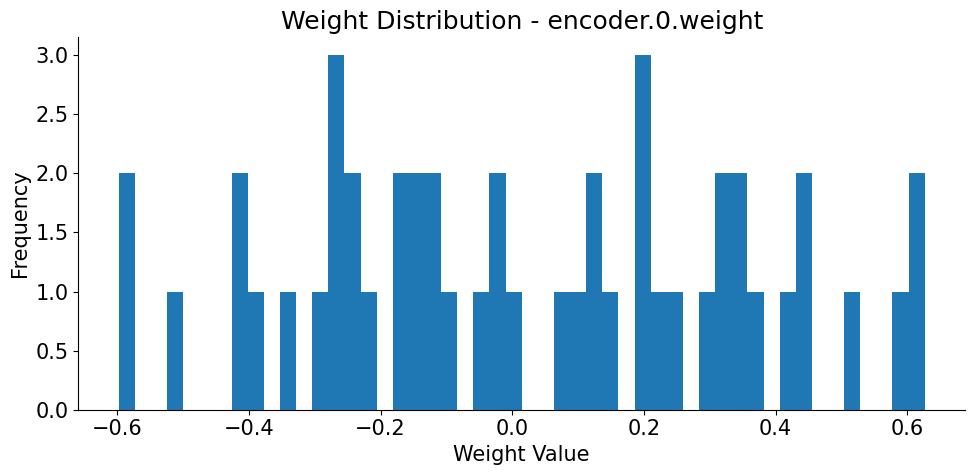

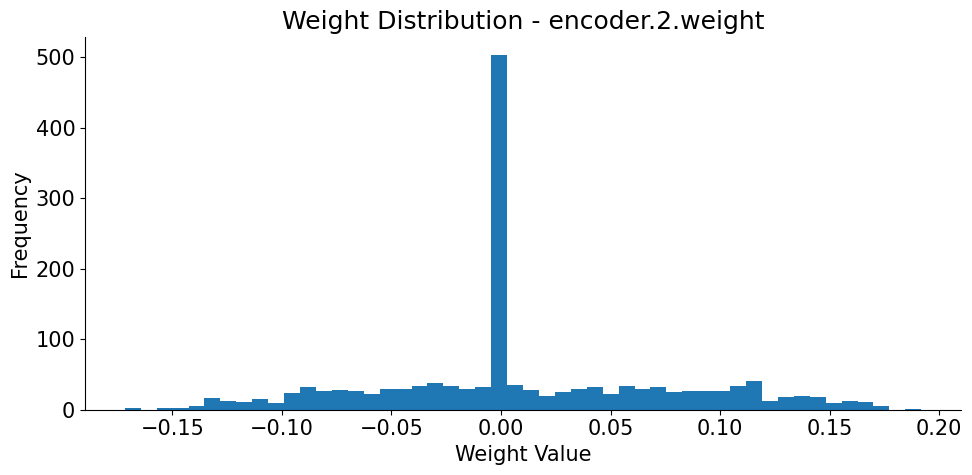

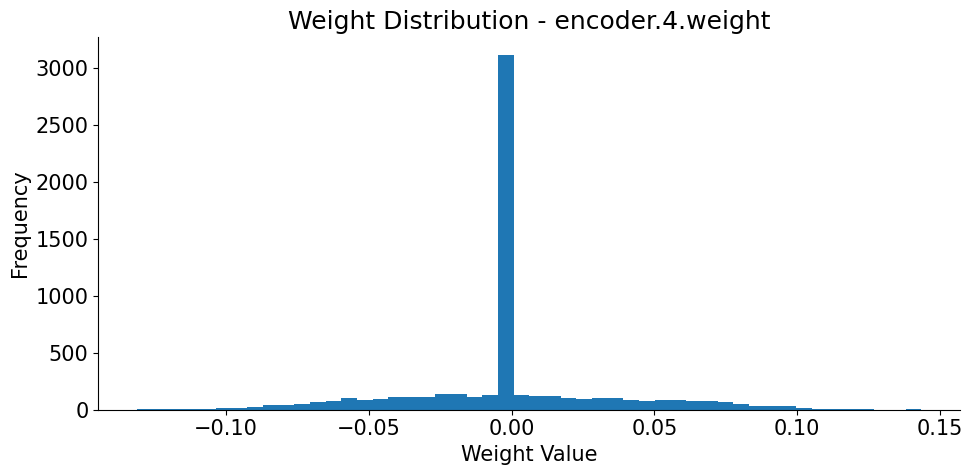

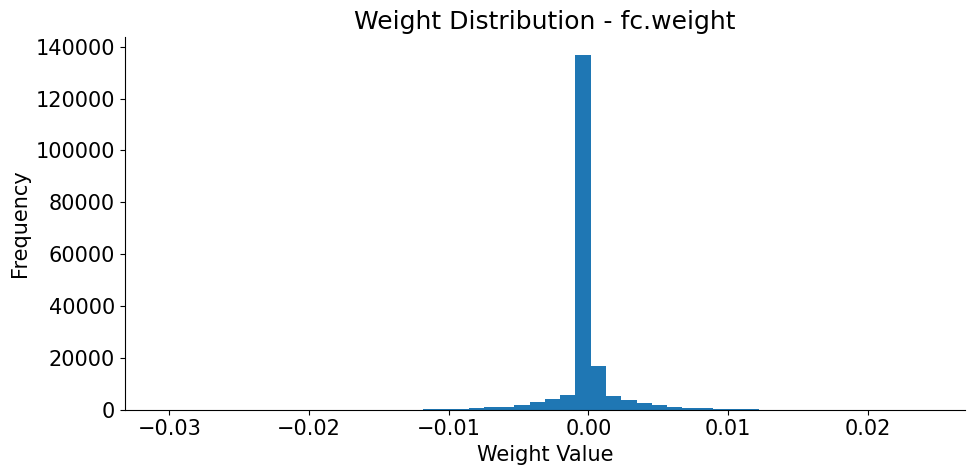

Training on Run...
Epoch [1/100], Train Loss: 0.7555, Val Loss: 0.4013
Epoch [2/100], Train Loss: 0.2977, Val Loss: 0.2094
Epoch [3/100], Train Loss: 0.1823, Val Loss: 0.1813
Epoch [4/100], Train Loss: 0.1377, Val Loss: 0.1586
Epoch [5/100], Train Loss: 0.1162, Val Loss: 0.1615
Epoch [6/100], Train Loss: 0.1009, Val Loss: 0.1627
Epoch [7/100], Train Loss: 0.1217, Val Loss: 0.1727
Epoch [8/100], Train Loss: 0.1194, Val Loss: 0.2146
Epoch [9/100], Train Loss: 0.1038, Val Loss: 0.1461
Epoch [10/100], Train Loss: 0.0879, Val Loss: 0.1525
Epoch [11/100], Train Loss: 0.0885, Val Loss: 0.1520
Epoch [12/100], Train Loss: 0.0953, Val Loss: 0.1767
Epoch [13/100], Train Loss: 0.1407, Val Loss: 0.2592
Epoch [14/100], Train Loss: 0.1363, Val Loss: 0.1524
Epoch [15/100], Train Loss: 0.1262, Val Loss: 0.2264
Epoch [16/100], Train Loss: 0.1194, Val Loss: 0.1725
Epoch [17/100], Train Loss: 0.1169, Val Loss: 0.1889
Epoch [18/100], Train Loss: 0.1099, Val Loss: 0.2085
Epoch [19/100], Train Loss: 0.1132, 

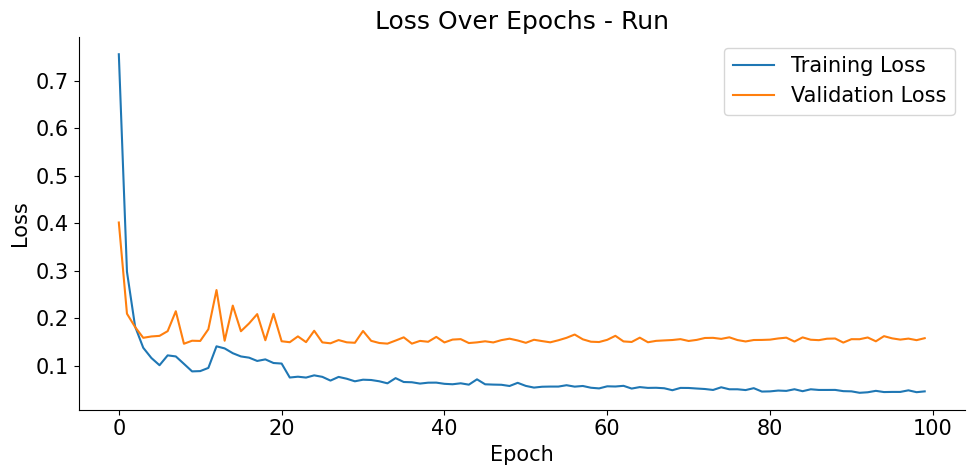

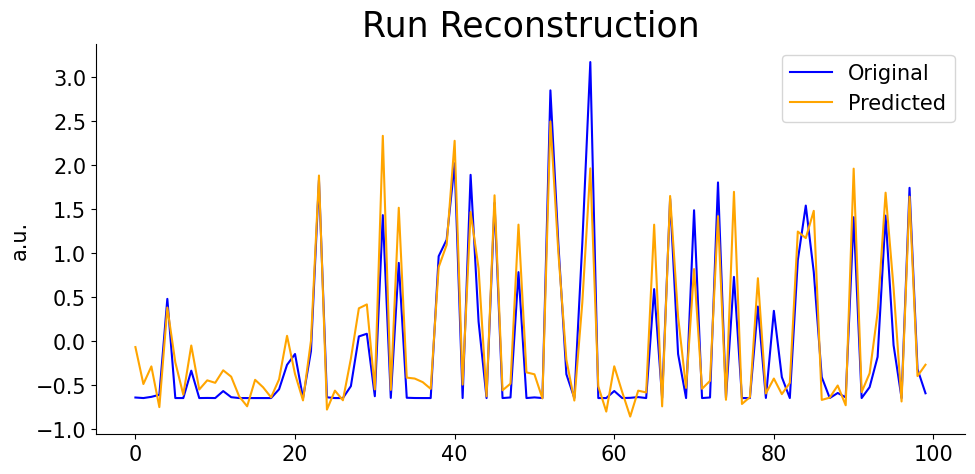

Correlation for Run: 0.9378
MSE for Run: 0.1140
R^2 for Run: 0.8795


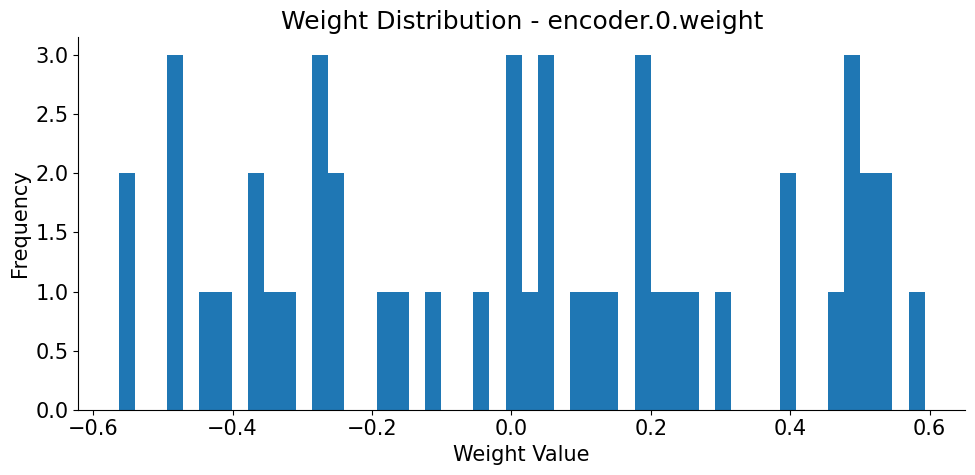

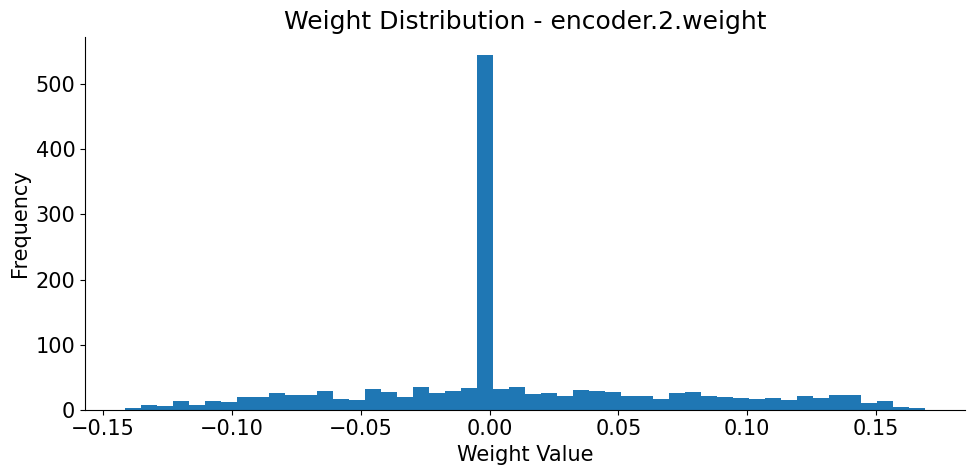

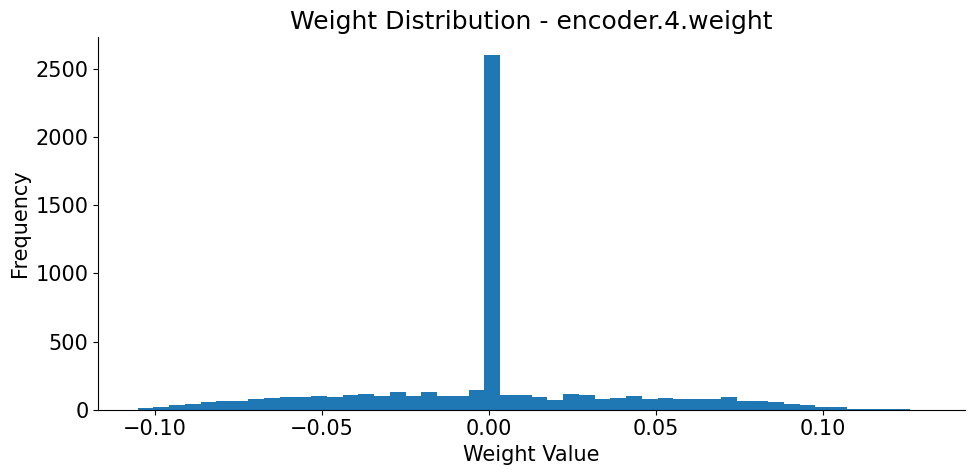

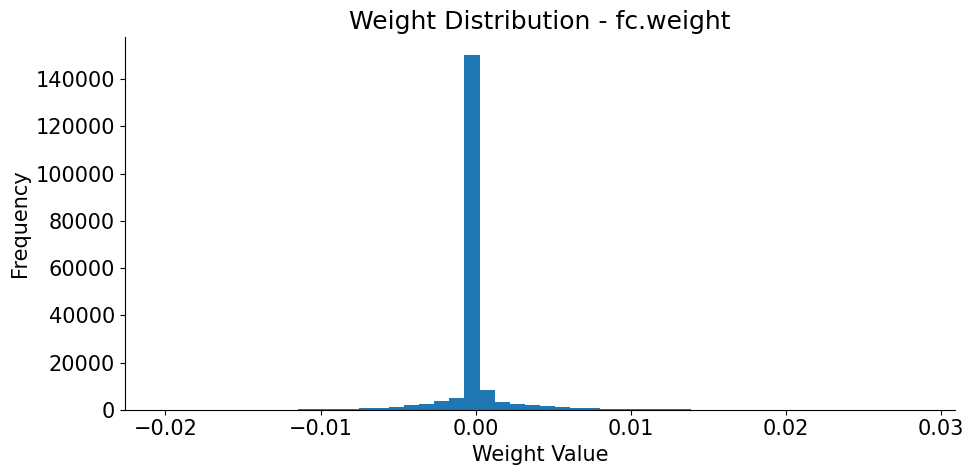

Training on Acceleration...
Epoch [1/100], Train Loss: 1.0176, Val Loss: 0.8770
Epoch [2/100], Train Loss: 0.6842, Val Loss: 0.5013
Epoch [3/100], Train Loss: 0.4553, Val Loss: 0.4660
Epoch [4/100], Train Loss: 0.3533, Val Loss: 0.4178
Epoch [5/100], Train Loss: 0.2940, Val Loss: 0.4384
Epoch [6/100], Train Loss: 0.2563, Val Loss: 0.4078
Epoch [7/100], Train Loss: 0.2275, Val Loss: 0.4417
Epoch [8/100], Train Loss: 0.1970, Val Loss: 0.4174
Epoch [9/100], Train Loss: 0.1783, Val Loss: 0.3973
Epoch [10/100], Train Loss: 0.1603, Val Loss: 0.4255
Epoch [11/100], Train Loss: 0.1575, Val Loss: 0.4251
Epoch [12/100], Train Loss: 0.1563, Val Loss: 0.4029
Epoch [13/100], Train Loss: 0.1556, Val Loss: 0.4182
Epoch [14/100], Train Loss: 0.1347, Val Loss: 0.4285
Epoch [15/100], Train Loss: 0.1370, Val Loss: 0.4257
Epoch [16/100], Train Loss: 0.1356, Val Loss: 0.4336
Epoch [17/100], Train Loss: 0.1274, Val Loss: 0.4115
Epoch [18/100], Train Loss: 0.1242, Val Loss: 0.4209
Epoch [19/100], Train Loss:

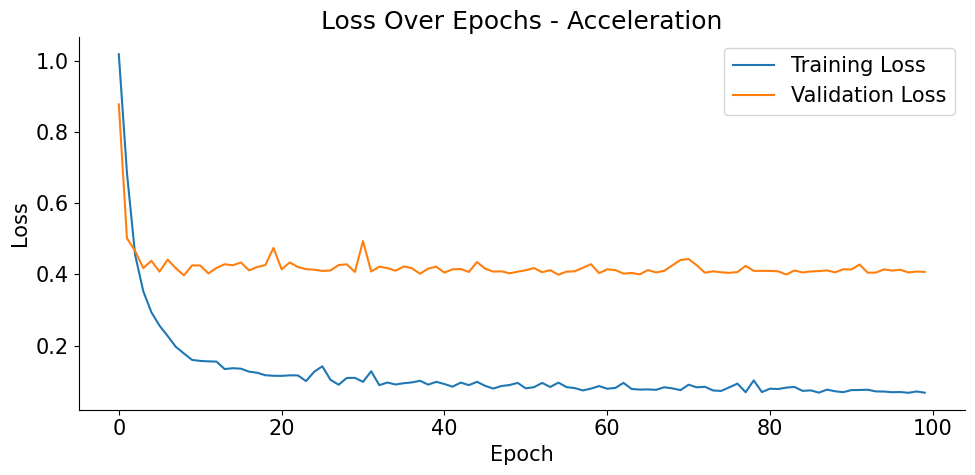

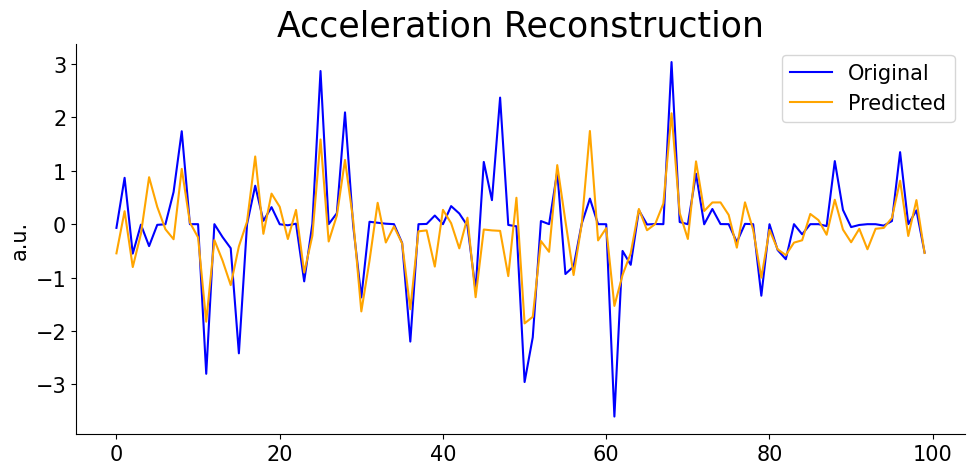

Correlation for Acceleration: 0.7823
MSE for Acceleration: 0.3742
R^2 for Acceleration: 0.6120


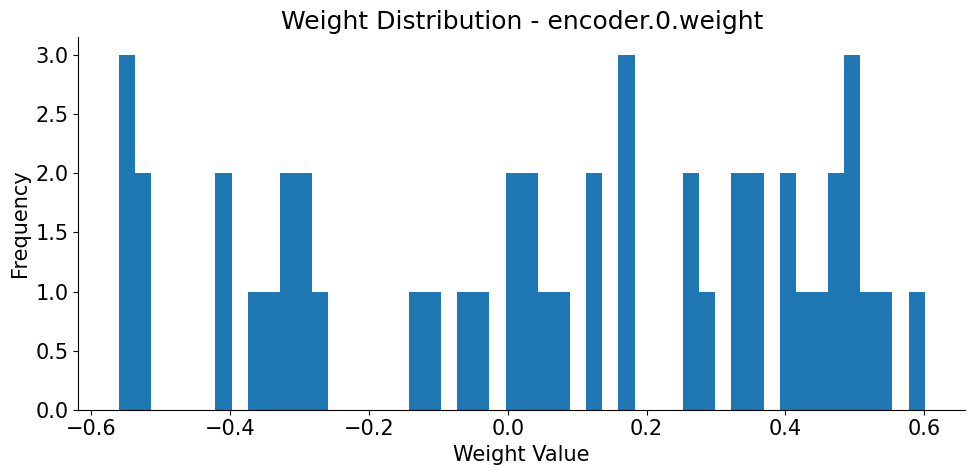

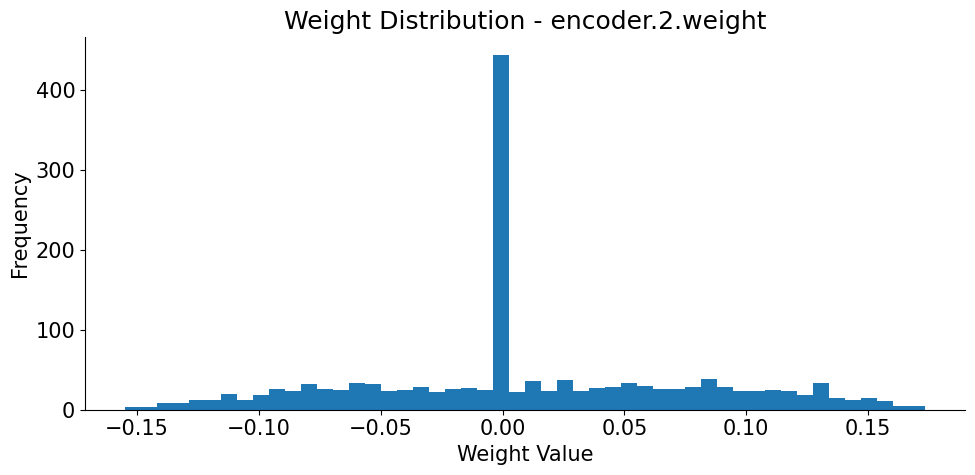

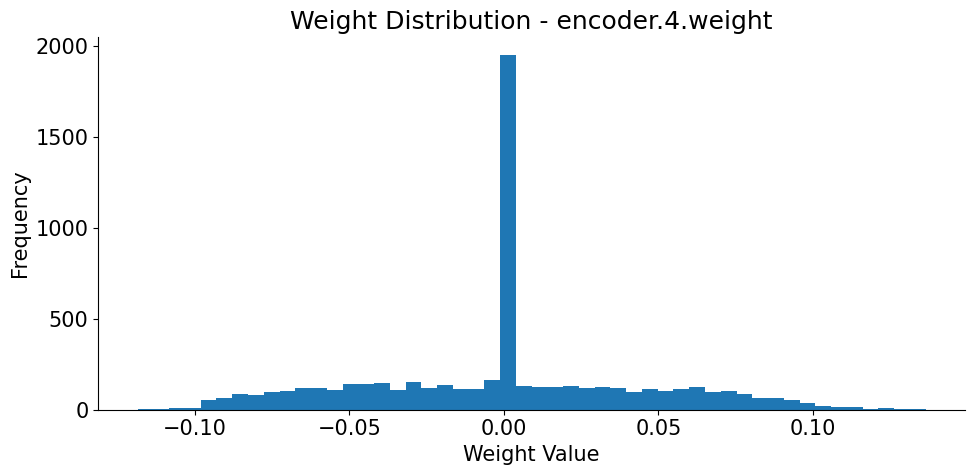

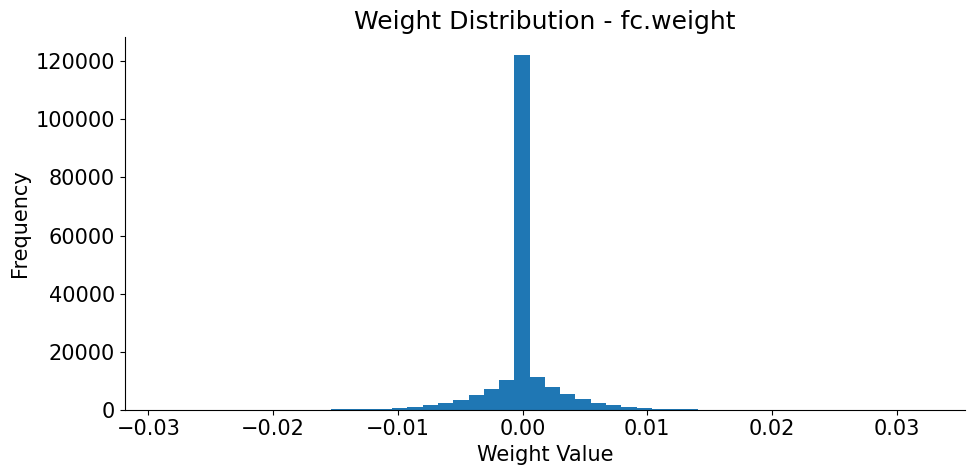

Average Correlation: 0.8768
Overall MSE: 0.2186
Average R^2: 0.7734


In [20]:
# @title CNN

# Assuming dat is your data dictionary containing pupilArea, sresp, pupilCOM, run, and beh_svd_time
i_stim = dat['istim']
run = dat['run']
acceleration = acceleration  # dat['run'][1:] - dat['run'][:-1]
neural_activity = dat['sresp'].T  # Transpose to match the expected shape [samples, features]

# Ensure the number of samples match
num_samples = min(i_stim.shape[0], run.shape[0], acceleration.shape[0], neural_activity.shape[0])

i_stim = i_stim[:num_samples]
run = run[:num_samples]
acceleration = acceleration[:num_samples]
neural_activity = neural_activity[:num_samples]

# Handle NaN values before normalization
i_stim = handle_na(i_stim)
run = handle_na(run)
acceleration = handle_na(acceleration)
neural_activity = handle_na_inf(neural_activity)

# Normalize pupil area, pupil COM, run, behavior SVD, and neural activity
i_stim = zscore(i_stim)
run = zscore(run)
acceleration = zscore(acceleration)
neural_activity = zscore(neural_activity)

# Convert to tensors
i_stim_tensor = torch.tensor(i_stim, dtype=torch.float32)
run_tensor = torch.tensor(run, dtype=torch.float32)
acceleration_tensor = torch.tensor(acceleration, dtype=torch.float32)
neural_activity_tensor = torch.tensor(neural_activity, dtype=torch.float32)

# Define the Sparse Convolutional Autoencoder
class SparseConvAutoencoder(nn.Module):
    def __init__(self, input_channels, output_size, input_length):
        super(SparseConvAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(input_channels, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        self.conv_output_size = self._get_conv_output_size(input_length)
        self.fc = nn.Linear(self.conv_output_size, output_size)

    def _get_conv_output_size(self, input_length):
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, input_length)
            conv_output = self.encoder(dummy_input)
            return int(torch.prod(torch.tensor(conv_output.size()[1:])))

    def forward(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def l1_penalty(model):
    l1_norm = 0
    for name, param in model.named_parameters():
        if 'bias' not in name and param.requires_grad:
            l1_norm += param.abs().sum()
    return l1_norm

# Parameters
input_channels = 1
num_epochs = 100
learning_rate = 0.0001
input_length = neural_activity_tensor.shape[1]
l1_lambda = 0.0001

# Function to create DataLoader
def create_dataloader(neural_activity, modality):
    dataset = TensorDataset(neural_activity, modality)
    train_size = int(0.6 * len(dataset))
    val_size = int(0.2 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    train_data, validation_data, test_data = random_split(dataset, [train_size, val_size, test_size])
    train_loader = DataLoader(train_data, batch_size=100, shuffle=True)
    validation_loader = DataLoader(validation_data, batch_size=100, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=100, shuffle=False)
    return train_loader, validation_loader, test_loader

# Function to train and evaluate the model for each modality
def train_modality(modality_name, modality_tensor):
    print(f"Training on {modality_name}...")
    train_loader, validation_loader, test_loader = create_dataloader(neural_activity_tensor, modality_tensor)
    output_size = modality_tensor.shape[1]
    model = SparseConvAutoencoder(input_channels, output_size, input_length).to(device)
    model = model.float().to(device)  # Ensure model parameters are float32

    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    track_loss = []
    val_loss = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        for inputs, targets in train_loader:
            inputs = inputs.unsqueeze(1).to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            mse_loss = loss_function(outputs, targets)
            l1_loss = l1_penalty(model)
            loss = mse_loss + l1_lambda * l1_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * inputs.size(0)

        avg_train_loss = epoch_loss / len(train_loader.dataset)
        track_loss.append(avg_train_loss)

        model.eval()
        val_epoch_loss = 0
        with torch.no_grad():
            for inputs, targets in validation_loader:
                inputs = inputs.unsqueeze(1).to(device)
                targets = targets.to(device)
                outputs = model(inputs)
                loss = loss_function(outputs, targets)
                val_epoch_loss += loss.item() * inputs.size(0)

        avg_val_loss = val_epoch_loss / len(validation_loader.dataset)
        val_loss.append(avg_val_loss)

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    plt.figure(figsize=(10, 5))
    plt.plot(track_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title(f'Loss Over Epochs - {modality_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    return model, test_loader

# Function to plot true vs predicted values
def plot_true_pred(y_true, y_pred, title, savefig=False):
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot()
    ax.set_title(title)
    ax.set_title(title, fontsize=25)
    ax.plot(y_true, color="blue", label="Original")
    ax.plot(y_pred, color="orange", label="Predicted")
    ax.set_ylabel("a.u.")
    ax.legend()
    plt.show()

# Function to visualize reconstruction
def visualize_reconstruction(modality_name, model, test_loader, reconstructions, true_values):
    model.eval()
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.unsqueeze(1).to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            break

    targets_np = targets.cpu().numpy()
    outputs_np = outputs.cpu().numpy()

    # Store reconstruction in dictionary
    reconstructions[modality_name] = outputs_np
    true_values[modality_name] = targets_np

    plot_true_pred(targets_np[:, 0], outputs_np[:, 0], title=f'{modality_name} Reconstruction')

    valid_indices = ~np.isnan(targets_np[:, 0]) & ~np.isnan(outputs_np[:, 0])
    if valid_indices.any():
        corr = pearsonr(targets_np[valid_indices, 0], outputs_np[valid_indices, 0])[0]
    else:
        corr = np.nan
    mse = np.mean((targets_np[:, 0] - outputs_np[:, 0]) ** 2)

    # Calculate R^2 scores
    r2 = corr ** 2

    print(f'Correlation for {modality_name}: {corr:.4f}')
    print(f'MSE for {modality_name}: {mse:.4f}')
    print(f'R^2 for {modality_name}: {r2:.4f}')

    return corr, mse, r2

# Function to visualize weights
def visualize_weights(model):
    for name, param in model.named_parameters():
        if 'weight' in name:
            plt.figure(figsize=(10, 5))
            plt.title(f'Weight Distribution - {name}')
            plt.hist(param.detach().cpu().numpy().flatten(), bins=50)
            plt.xlabel('Weight Value')
            plt.ylabel('Frequency')
            plt.show()

# List of modalities and their corresponding tensors
modalities = {
    'Stimulus Orientation': i_stim_tensor,
    'Run': run_tensor,
    'Acceleration': acceleration_tensor,
}

# Train and evaluate the model for each modality
all_correlations = []
all_mses = []
all_r2s = []
reconstructions = {}
true_values = {}

for modality_name, modality_tensor in modalities.items():
    model, test_loader = train_modality(modality_name, modality_tensor)
    corr, mse, r2 = visualize_reconstruction(modality_name, model, test_loader, reconstructions, true_values)
    visualize_weights(model)
    all_correlations.append(corr)
    all_mses.append(mse)
    all_r2s.append(r2)

# Print average correlation, overall MSE, and average R^2
print(f'Average Correlation: {np.nanmean(all_correlations):.4f}')
print(f'Overall MSE: {np.mean(all_mses):.4f}')
print(f'Average R^2: {np.nanmean(all_r2s):.4f}')

# Save reconstructions to file
# reconstructions_path = os.path.expanduser('~/Desktop/reconstructions.npz')
# true_values_path = os.path.expanduser('~/Desktop/true_values.npz')

# np.savez(reconstructions_path, **reconstructions)
# np.savez(true_values_path, **true_values)


Training on Superneurons (i_stim)...
Epoch [1/100], Train Loss: 0.2384, Val Loss: 0.1204
Epoch [2/100], Train Loss: 0.1468, Val Loss: 0.0848
Epoch [3/100], Train Loss: 0.1126, Val Loss: 0.0717
Epoch [4/100], Train Loss: 0.0978, Val Loss: 0.0702
Epoch [5/100], Train Loss: 0.0875, Val Loss: 0.0676
Epoch [6/100], Train Loss: 0.0806, Val Loss: 0.0637
Epoch [7/100], Train Loss: 0.0764, Val Loss: 0.0693
Epoch [8/100], Train Loss: 0.0737, Val Loss: 0.0805
Epoch [9/100], Train Loss: 0.0739, Val Loss: 0.0601
Epoch [10/100], Train Loss: 0.0674, Val Loss: 0.0591
Epoch [11/100], Train Loss: 0.0703, Val Loss: 0.0602
Epoch [12/100], Train Loss: 0.0667, Val Loss: 0.0587
Epoch [13/100], Train Loss: 0.0713, Val Loss: 0.0610
Epoch [14/100], Train Loss: 0.0654, Val Loss: 0.0655
Epoch [15/100], Train Loss: 0.0675, Val Loss: 0.0658
Epoch [16/100], Train Loss: 0.0653, Val Loss: 0.0666
Epoch [17/100], Train Loss: 0.0615, Val Loss: 0.0612
Epoch [18/100], Train Loss: 0.0598, Val Loss: 0.0582
Epoch [19/100], Tr

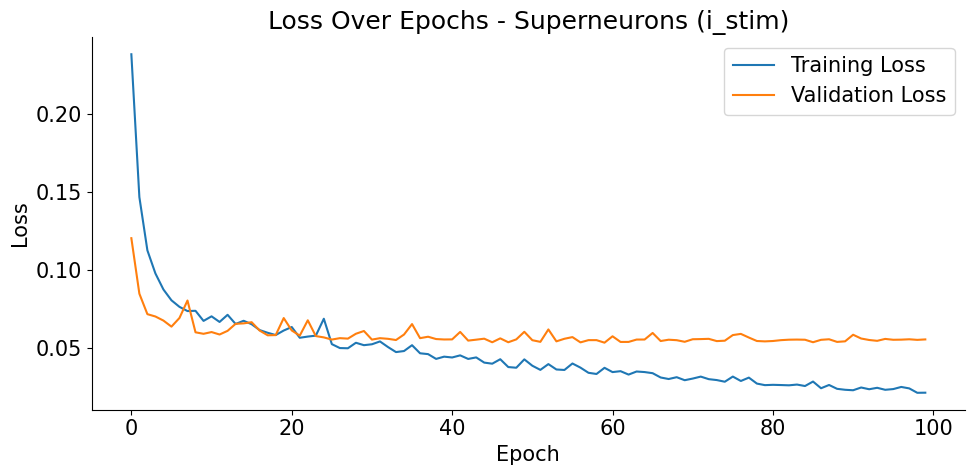

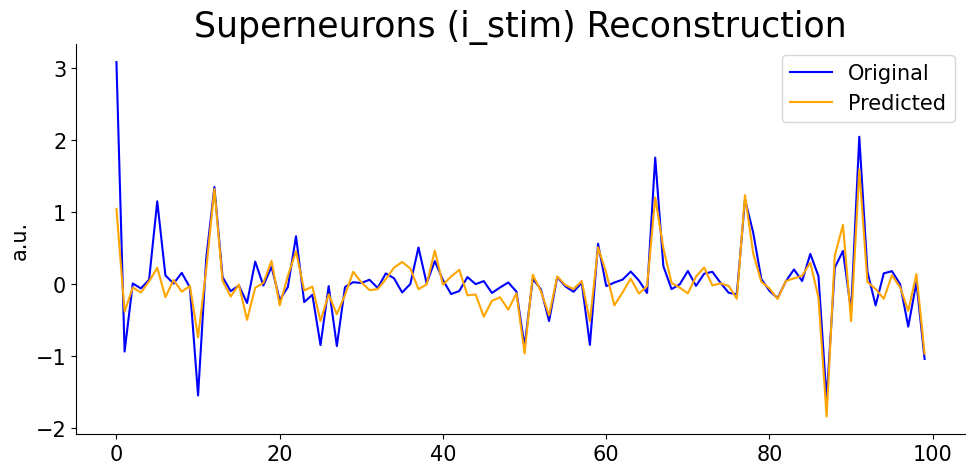

Correlation for Superneurons (i_stim): 0.8563
MSE for Superneurons (i_stim): 0.0995
R^2 for Superneurons (i_stim): 0.7332
Performance for i_stim: Correlation: 0.8563, MSE: 0.0995, R²: 0.7332


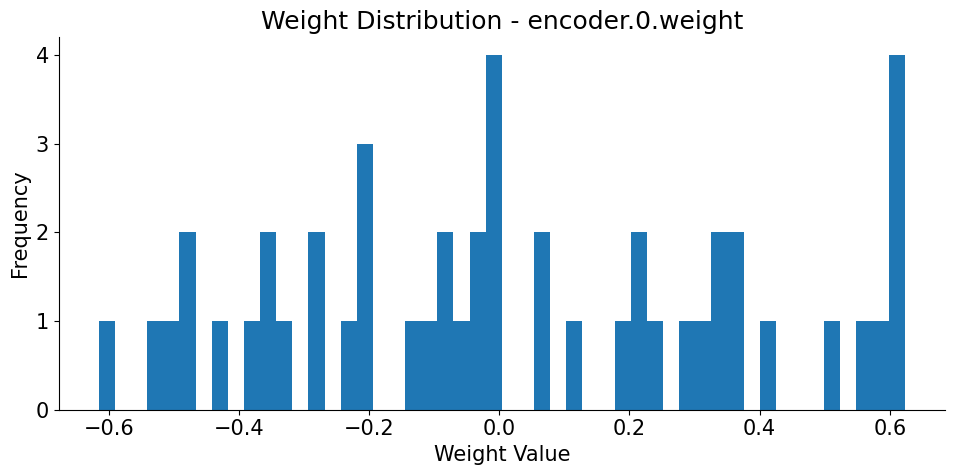

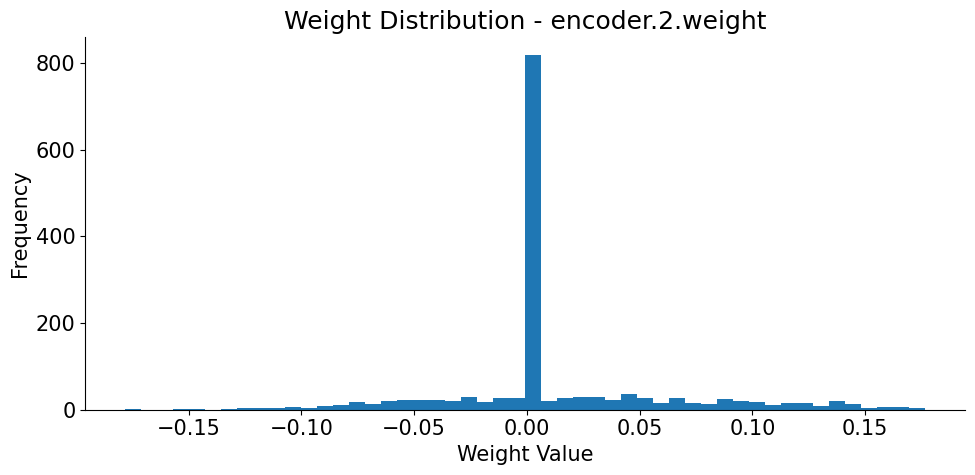

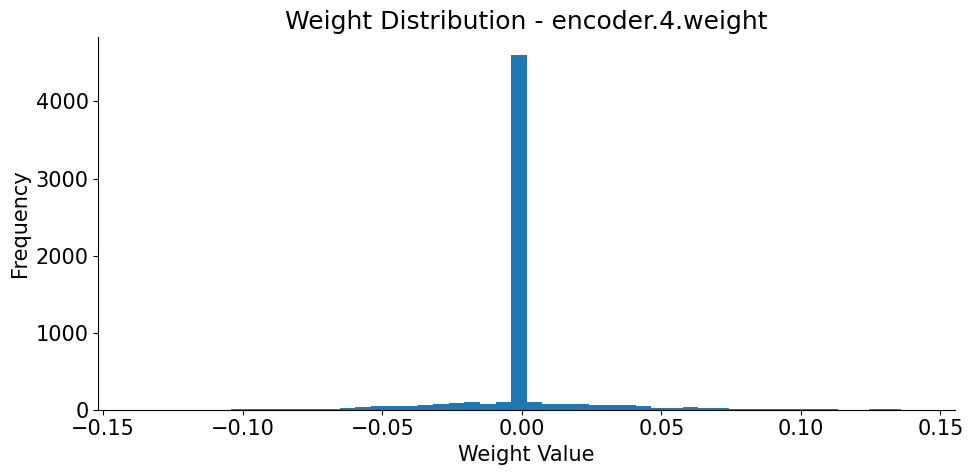

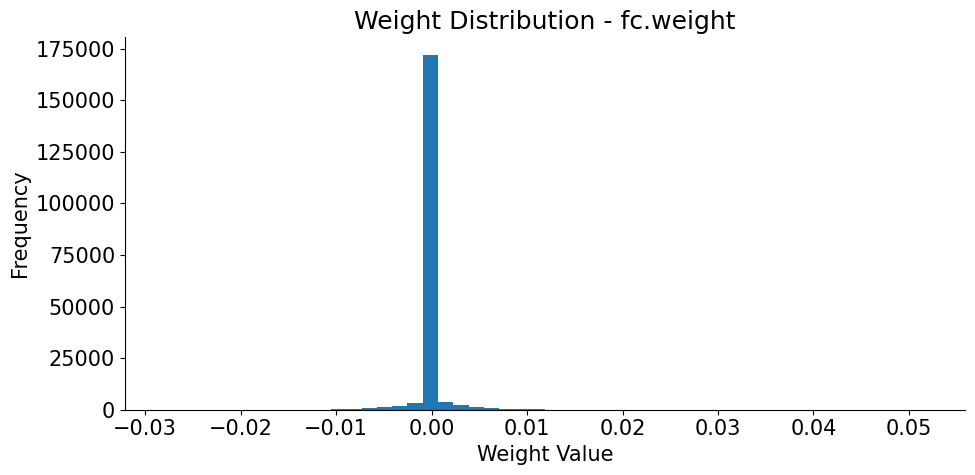

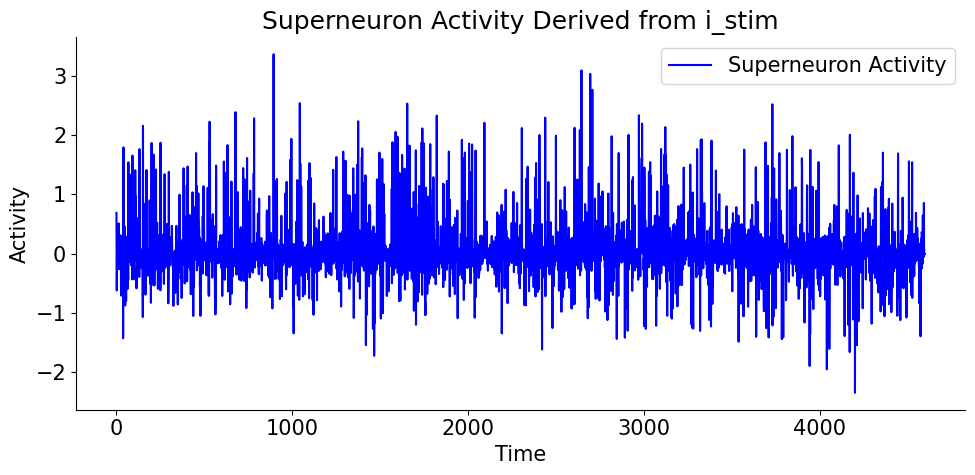

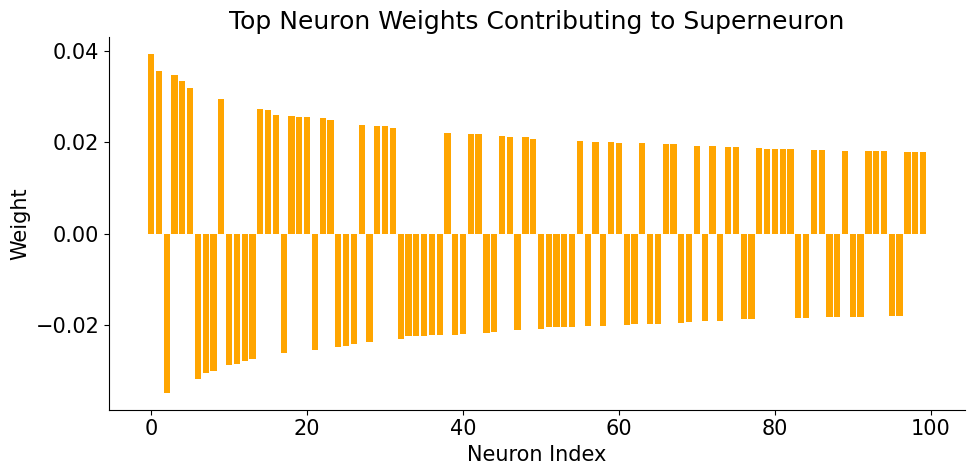

In [36]:
# @title CNN on Superneurons

# Define superneurons based on the specific modality
def create_superneurons(sresp_tensor, modality_tensor, top_k=100):
    """
    Create superneurons for a specific modality by aggregating the activity of top_k neurons.

    Args:
        sresp_tensor (torch.Tensor): Neural activity tensor (samples x neurons).
        modality_tensor (torch.Tensor): Target modality tensor (samples x 1).
        top_k (int): Number of top neurons to include in the superneurons.

    Returns:
        torch.Tensor: Superneurons tensor (samples x 1).
        np.ndarray: Weights of the top predictive neurons.
    """
    # Train a linear regression model to predict modality from neural activity
    x_np = sresp_tensor.numpy()  # Neural activity
    y_np = modality_tensor.numpy()  # Modality target
    model = LinearRegression().fit(x_np, y_np)

    # Extract weights and rank neurons by their predictive power
    weights = model.coef_[0]  # Linear regression weights (1 x neurons)
    top_neuron_indices = np.argsort(np.abs(weights))[::-1][:top_k]  # Top k neurons by absolute weight
    top_neuron_indices = np.array(top_neuron_indices)
    # Select the top neurons and compute weighted activity
    selected_sresp = sresp_tensor[:, top_neuron_indices].clone().contiguous()
    weighted_activity = selected_sresp * torch.tensor(weights[top_neuron_indices], dtype=torch.float32)

    # Define the superneuron as the sum of weighted activity
    superneuron = torch.sum(weighted_activity, axis=1).unsqueeze(1)  # Shape: (samples, 1)
    return superneuron, weights[top_neuron_indices]

# Train and evaluate model using superneurons
def train_with_superneurons_for_istim(sresp_tensor, modality_tensor, top_k=100):
    """
    Train a model using superneurons derived from `i_stim` modality.

    Args:
        sresp_tensor (torch.Tensor): Neural activity tensor.
        modality_tensor (torch.Tensor): Target modality tensor (i_stim in this case).
        top_k (int): Number of top neurons to include in the superneurons.

    Returns:
        None
    """
    # Create superneurons specifically for `i_stim`
    superneurons_tensor, top_weights = create_superneurons(sresp_tensor, modality_tensor, top_k=top_k)

    # Create DataLoader
    dataset = TensorDataset(superneurons_tensor, modality_tensor)
    train_loader, validation_loader, test_loader = create_dataloader(superneurons_tensor, modality_tensor)

    # Train the model
    model, test_loader = train_modality("Superneurons (i_stim)", superneurons_tensor)

    # Evaluate performance
    reconstructions = {}
    true_values = {}
    corr, mse, r2 = visualize_reconstruction(
        "Superneurons (i_stim)", model, test_loader, reconstructions, true_values
    )
    print(f"Performance for i_stim: Correlation: {corr:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")
    visualize_weights(model)

    # Plot superneurons and their top contributing weights
    plt.figure(figsize=(10, 5))
    plt.plot(superneurons_tensor.numpy(), label="Superneuron Activity", color="blue")
    plt.title("Superneuron Activity Derived from i_stim")
    plt.xlabel("Time")
    plt.ylabel("Activity")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(top_weights)), top_weights, color="orange")
    plt.title("Top Neuron Weights Contributing to Superneuron")
    plt.xlabel("Neuron Index")
    plt.ylabel("Weight")
    plt.show()

# Example: Train the model with superneurons derived from `i_stim`
train_with_superneurons_for_istim(sresp_tensor, i_stim_tensor, top_k=100)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Set random seed for reproducibility
tf.random.set_seed(42)


# Assuming 'acceleration' data is correctly defined somewhere above this block
# Example:
# acceleration = dat['run'][1:] - dat['run'][:-1] + np.random.normal(0, 0.1, size=dat['run'].shape[0]-1)

# Prepare data
i_stim = handle_na(zscore(dat['istim']))
run = handle_na(zscore(dat['run']))
neural_activity = handle_na(zscore(dat['sresp'].T))  # Transpose if necessary

# Assuming we have 'acceleration' data
acceleration = handle_na(zscore(np.diff(dat['run'], prepend=0)))

# Concatenate all features into a single matrix for LSTM input
features = np.column_stack((i_stim, run, acceleration))

# Define sequence length
seq_length = 50
dataset_size = len(neural_activity)
num_features = features.shape[1]

# Reshape data into (samples, sequence, features)
X = np.array([features[i: i + seq_length] for i in range(dataset_size - seq_length)])
y = np.array([neural_activity[i + seq_length] for i in range(dataset_size - seq_length)])

# Split dataset
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the LSTM model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(seq_length, num_features)),
    LSTM(64),
    Dropout(0.2),
    Dense(y_train.shape[1], activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.005), loss='mean_squared_error')

# Training the model
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_val, y_val), verbose=1)

# Plotting the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate the model
predictions = model.predict(X_val)
correlation = np.corrcoef(y_val.flatten(), predictions.flatten())[0, 1]
mse = np.mean((y_val.flatten() - predictions.flatten()) ** 2)

print(f'Correlation: {correlation:.4f}')
print(f'Mean Squared Error: {mse:.4f}')


In [ ]:
# @title LSTM (KERAS) Decoder

tf.random.set_seed(42)


# Load and preprocess data
neural_activity = dat['sresp'].T  # Ensure neural activity is in the right shape
i_stim = dat['istim']
acceleration = acceleration
run = dat['run']

# Define the LSTM model with regularization
def create_lstm_model(input_shape, output_size, l2_factor=0.01, dropout_rate=0.2):
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape, kernel_initializer='he_uniform'))
    model.add(LSTM(64, return_sequences=False, kernel_initializer='he_uniform', kernel_regularizer=tf.keras.regularizers.l2(l2_factor)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(output_size, activation='linear', kernel_initializer='he_uniform'))

    model.compile(optimizer=Adam(learning_rate=0.005), loss='mean_squared_error')
    return model

# Function to prepare the dataset
def prepare_dataset(neural_activity, modality, seq_length):
    # Ensure the number of samples is a multiple of the sequence length
    num_complete_batches = min(neural_activity.shape[0], modality.shape[0]) // seq_length

    # Reshape data into sequences
    neural_activity_reshaped = neural_activity[:num_complete_batches * seq_length].reshape(-1, seq_length, neural_activity.shape[1])
    modality_reshaped = modality[:num_complete_batches * seq_length].reshape(-1, seq_length, 1)

    # Ensure equal number of samples
    num_samples = min(neural_activity_reshaped.shape[0], modality_reshaped.shape[0])
    neural_activity_reshaped = neural_activity_reshaped[:num_samples]
    modality_reshaped = modality_reshaped[:num_samples]

    # Split data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(neural_activity_reshaped, modality_reshaped[:, -1, :], test_size=0.2, random_state=42)

    return X_train, X_val, y_train, y_val

# Training function with regularization parameters and additional metrics
def train_and_evaluate(X_train, X_val, y_train, y_val, modality_name, seq_length, l2_factor=0.01, dropout_rate=0.2):
    input_shape = (seq_length, X_train.shape[2])
    output_size = y_train.shape[1]

    model = create_lstm_model(input_shape, output_size, l2_factor, dropout_rate)
    history = model.fit(X_train, y_train, epochs=100, batch_size=100, validation_data=(X_val, y_val), verbose=2)

    # Plotting the loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{modality_name} - Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Make predictions
    y_pred = model.predict(X_val)

    # Visualize original and reconstructed data
    plt.figure(figsize=(12, 6))

    # Original Data
    plt.subplot(1, 2, 1)
    plt.plot(np.arange(len(y_val[:30])), y_val[:30], label=f'Original {modality_name}')
    plt.title(f'Original {modality_name}')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()

    # Reconstructed Data
    plt.subplot(1, 2, 2)
    plt.plot(np.arange(len(y_pred[:30])), y_pred[:30], label=f'Reconstructed {modality_name}')
    plt.title(f'Reconstructed {modality_name}')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()

    plt.show()

    # Calculate MSE, correlation, and R²
    y_val_flat = y_val.flatten()
    y_pred_flat = y_pred.flatten()

    correlation = np.corrcoef(y_val_flat, y_pred_flat)[0, 1]
    overall_mse = mean_squared_error(y_val_flat, y_pred_flat)
    r2 = r2_score(y_val_flat, y_pred_flat)

    print(f'{modality_name} - Correlation: {correlation:.4f}')
    print(f'{modality_name} - Overall MSE: {overall_mse:.4f}')
    print(f'{modality_name} - R²: {r2:.4f}')

neural_activity = zscore(neural_activity)
i_stim = zscore(i_stim)
acceleration = zscore(acceleration)
run = zscore(run)

neural_activity = handle_na_inf(neural_activity)
i_stim = handle_na_inf(i_stim)
acceleration = handle_na_inf(acceleration)
run = handle_na_inf(run)

# Prepare and train the model for each modality
seq_length = 100

for modality, name in zip([i_stim, run, acceleration], ['Stimuli', 'Run', 'Acceletration']):
    print(f"Processing modality: {name}")
    X_train, X_val, y_train, y_val = prepare_dataset(neural_activity, modality, seq_length)
    train_and_evaluate(X_train, X_val, y_train, y_val, name, seq_length)


In [ ]:
# Normalize the data
def normalize_data(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1  # Avoid division by zero
    return (data - mean) / std

# Handling NaN values in the dataset by replacing with mean
def handle_na(data):
    df = pd.DataFrame(data)
    df.fillna(df.mean(), inplace=True)
    return df.to_numpy()

# Assuming dat is your data dictionary containing pupilArea, sresp, and pupilCOM
i_stim = dat['istim']
sresp = dat['sresp']
acceleration = acceleration
run = dat['run']

# Ensure the number of samples match
num_samples = min(i_stim.shape[0], run.shape[0], sresp.shape[1])

i_stim = i_stim[:num_samples]
run = run[:num_samples]
acceleration = acceleration[:num_samples]
sresp = sresp[:, :num_samples]

# Handle NaN values before normalization
i_stim = handle_na(i_stim)
run = handle_na(run)
acceleration = handle_na(acceleration)
sresp = handle_na(sresp)

# Normalize the neural activity data
sresp_zscored = normalize_data(sresp)
sresp_tensor_zscored = torch.tensor(sresp_zscored, dtype=torch.float32).transpose(0, 1)

# Normalize i_stim and run
i_stim = normalize_data(i_stim)
run = normalize_data(run)
acceleration = normalize_data(acceleration)
sresp = normalize_data(sresp)

# Convert to tensors
i_stim_tensor = torch.tensor(i_stim, dtype=torch.float32).view(-1, 1)
run_tensor = torch.tensor(run, dtype=torch.float32)
acceleration_tensor = torch.tensor(acceleration, dtype=torch.float32)
sresp_tensor_zscored = torch.tensor(sresp_tensor_zscored, dtype=torch.float32)

print(run_tensor)  # Check values after handling NaN

# Concatenate i_stim and run along the feature dimension
input_tensor = torch.cat((i_stim_tensor, run_tensor, acceleration_tensor), dim=1)

# Create a TensorDataset
dataset = TensorDataset(input_tensor, sresp_tensor_zscored)

In [ ]:


# # Assuming `i_stim_tensor` and `sresp_tensor_zscored` are your input and output tensors
# print("Shape of i_stim_tensor:", i_stim_tensor.shape)
# print("Shape of sresp_tensor_zscored:", sresp_tensor_zscored.shape)

# # Prepare the dataset
# dataset = TensorDataset(input_tensor, sresp_tensor_zscored)

# # Split the dataset into training, validation, and testing
# train_data, temp_data = train_test_split(dataset, test_size=0.4, random_state=42)
# validation_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# # Create DataLoader for each dataset
# train_loader = DataLoader(train_data, batch_size=100, shuffle=True)
# validation_loader = DataLoader(validation_data, batch_size=100, shuffle=False)
# test_loader = DataLoader(test_data, batch_size=100, shuffle=False)

# # Extract the input and output tensors from the DataLoader
# train_inputs, train_labels = next(iter(train_loader))
# validation_inputs, validation_labels = next(iter(validation_loader))
# test_inputs, test_labels = next(iter(test_loader))

# # Convert DataLoader to a dictionary format that KAN expects
# dataset_dict = {
#     'train_input': train_inputs,
#     'train_label': train_labels,
#     'test_input': validation_inputs,
#     'test_label': validation_labels
# }

# # Create a KAN model: 1D inputs, 1D output, and 50 hidden neurons, cubic spline (k=3), 3 grid intervals (grid=3).
# model = KAN(width=[1,50,1], grid=3, k=3, seed=42, device=device)

# # Plot KAN at initialization (using a single batch from the training data)
# model(train_inputs.to(device))  # Forward pass

# # Plot the initialized model
# # model.plot()

# # Train the model using the dataset dictionary
# model.fit(dataset_dict.to, opt="LBFGS", steps=50, lamb=0.001)

# # Plot the trained model
# # model.plot()

In [ ]:
# @title Ridge Regression


# Apply PCA to reduce dimensionality of neural activity
pca = PCA(n_components=2177)  # Adjust based on your data
X_pca = pca.fit_transform(sresp_tensor.numpy())

# Ensure the target variable (acceleration) has the correct number of samples
y = run_tensor.reshape(-1)  # Ensure y has shape (4598,)

# Check the shapes of X and y to make sure they match
print(f"Shape of X_pca: {X_pca.shape}")
print(f"Shape of y: {y.shape}")

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(sresp_tensor, y, test_size=0.2, random_state=42)

# Continue with Ridge Regression as before
ridge_model = RidgeCV(alphas=np.logspace(-6, 6, 13), cv=5, scoring='neg_mean_squared_error')
ridge_model.fit(X_train, y_train)

# Predict and calculate MSE, correlation, and R² as before
y_pred_train = ridge_model.predict(X_train)
y_pred_test = ridge_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
print(f"Train MSE: {train_mse:.6f}")
print(f"Test MSE: {test_mse:.6f}")
print(f"Optimal alpha (regularization): {ridge_model.alpha_}")

# Correlation and R²
correlation_matrix = np.corrcoef(y_test.flatten(), y_pred_test.flatten())
correlation = correlation_matrix[0, 1]
print(f"Correlation: {correlation:.4f}")

r2 = r2_score(y_test, y_pred_test)
print(f"R²: {r2:.4f}")

# Plotting the original vs predicted data
plt.figure(figsize=(12, 6))
max_plot_points = min(1000, y_test.shape[0])

# Original Data
plt.subplot(1, 2, 1)
plt.plot(np.arange(max_plot_points), y_test[:max_plot_points], label='Original Modality')
plt.title('Original Modality Activity (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Modality')
plt.legend(loc='upper right')

# Predicted Data
plt.subplot(1, 2, 2)
plt.plot(np.arange(max_plot_points), y_pred_test[:max_plot_points], label='Predicted Modality')
plt.title('Predicted Modality Activity (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Modality')
plt.legend(loc='upper right')

plt.show()

Training on Stimulus Orientation (i_stim)...
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.23e+04 | test_loss: 3.03e+04 | reg: 1.63e+08 | : 100%|█| 100/100 [3:59:20<00:00, 143


saving model version 0.1


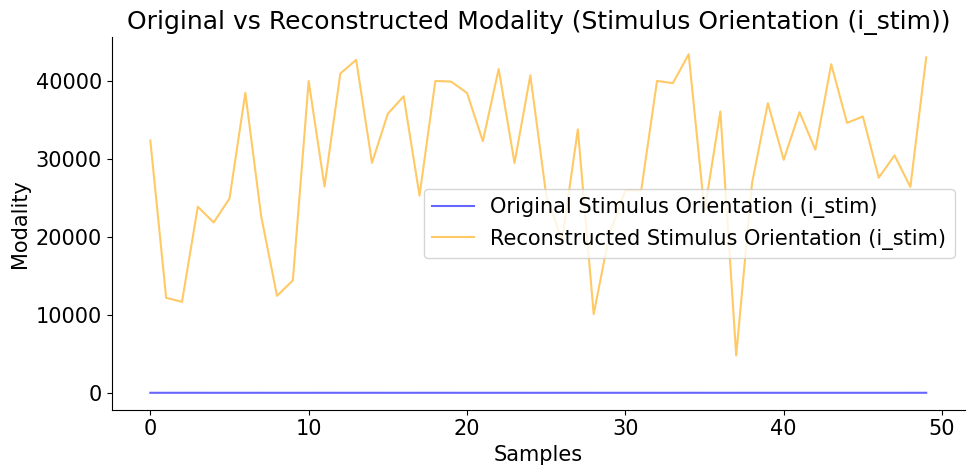

Correlation for Stimulus Orientation (i_stim): -0.1390
MSE for Stimulus Orientation (i_stim): 1001706386.0022
R² for Stimulus Orientation (i_stim): 0.0193
Training on Run...
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.25e+05 | test_loss: 7.96e+05 | reg: 1.07e+08 | :  15%|▏| 15/100 [1:01:33<3:00:07, 12

In [ ]:
# @title KAN Decoder

# Load modalities and neural activity
i_stim = dat['istim']
run = dat['run']
acceleration = acceleration
sresp = dat['sresp']

# Ensure the number of samples match
num_samples = min(i_stim.shape[0], run.shape[0], acceleration.shape[0], sresp.shape[1])
i_stim = i_stim[:num_samples]
run = run[:num_samples]
acceleration = acceleration[:num_samples]
sresp = sresp[:, :num_samples]

# Handle NaN values
i_stim = handle_na(i_stim)
run = handle_na(run)
acceleration = handle_na(acceleration)
sresp = handle_na(sresp)

# Normalize data
sresp_zscored = normalize_data(sresp)
i_stim = normalize_data(i_stim)
run = normalize_data(run)
acceleration = normalize_data(acceleration)

# Convert modalities and sresp to tensors
sresp_tensor = torch.tensor(sresp_zscored, dtype=torch.float64).transpose(0, 1)
i_stim_tensor = torch.tensor(i_stim, dtype=torch.float64).view(-1, 1)
run_tensor = torch.tensor(run, dtype=torch.float64).view(-1, 1)
acceleration_tensor = torch.tensor(acceleration, dtype=torch.float64).view(-1, 1)

# Define a function to train and evaluate the KAN model for a single modality
def train_modality_kan(modality_name, modality_tensor):
    print(f"Training on {modality_name}...")

    # Create a TensorDataset with sresp as input and the current modality as output
    dataset = TensorDataset(sresp_tensor, modality_tensor)

    # Split the dataset into training, validation, and testing
    train_data, temp_data = train_test_split(dataset, test_size=0.4, random_state=42)
    validation_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

    # Create DataLoader for each dataset
    train_loader = DataLoader(train_data, batch_size=50, shuffle=True)
    validation_loader = DataLoader(validation_data, batch_size=50, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=50, shuffle=False)

    # Extract input and labels from train_loader for initial forward pass
    train_inputs, train_labels = next(iter(train_loader))
    validation_inputs, validation_labels = next(iter(validation_loader))
    test_inputs, test_labels = next(iter(test_loader))

    # Convert DataLoader to a dictionary format that KAN expects
    dataset_dict = {
        'train_input': train_inputs,
        'train_label': train_labels,
        'test_input': validation_inputs,
        'test_label': validation_labels
    }

    # Initialize the KAN model
    model = KAN(width=[train_inputs.shape[1], 600, 1], grid=6, k=3, seed=42)
    model(train_inputs)  # Initial forward pass to initialize activations

    # Train the model
    model.fit(dataset_dict, opt="Adam", steps=100, lamb=0.0001)

    # Evaluate on test data
    with torch.no_grad():
        reconstructed_modality = model(test_inputs)

    # Convert tensors to numpy for evaluation and visualization
    original_modality = test_labels.numpy()
    reconstructed_modality = reconstructed_modality.numpy()

    # Plot original vs reconstructed modality
    plt.figure(figsize=(10, 5))
    plt.plot(original_modality[:, 0], label=f"Original {modality_name}", color="blue", alpha=0.6)
    plt.plot(reconstructed_modality[:, 0], label=f"Reconstructed {modality_name}", color="orange", alpha=0.6)
    plt.title(f"Original vs Reconstructed Modality ({modality_name})")
    plt.xlabel("Samples")
    plt.ylabel("Modality")
    plt.legend()
    plt.show()

    # Calculate performance metrics
    correlation = np.corrcoef(original_modality[:, 0], reconstructed_modality[:, 0])[0, 1]
    mse = np.mean((original_modality[:, 0] - reconstructed_modality[:, 0]) ** 2)
    r2 = correlation ** 2

    print(f"Correlation for {modality_name}: {correlation:.4f}")
    print(f"MSE for {modality_name}: {mse:.4f}")
    print(f"R² for {modality_name}: {r2:.4f}")

    return correlation, mse, r2

# Train and evaluate for each modality
modalities = {
    "Stimulus Orientation (i_stim)": i_stim_tensor,
    "Run": run_tensor,
    "Acceleration": acceleration_tensor
}

all_correlations = []
all_mses = []
all_r2s = []

for modality_name, modality_tensor in modalities.items():
    corr, mse, r2 = train_modality_kan(modality_name, modality_tensor)
    all_correlations.append(corr)
    all_mses.append(mse)
    all_r2s.append(r2)

# Print overall metrics
print(f"Average Correlation: {np.mean(all_correlations):.4f}")
print(f"Average MSE: {np.mean(all_mses):.4f}")
print(f"Average R²: {np.mean(all_r2s):.4f}")


In [ ]:
# Do a Pearson's correlation on sresps_der_tensor and acceleration
sresp_der_tensor = torch.tensor(sresp_der, dtype=torch.float64)
correlation = np.corrcoef(sresp_der_tensor.flatten(), combined_modality_tensor.flatten())[0, 1]
print(f'Correlation: {correlation:.4f}')

# Plot a scatter plot to visually analyze the correlation
plt.scatter(sresp_der_tensor.flatten(), acceleration_tensor.flatten())
plt.xlabel('sresp_der')
plt.ylabel('acceleration')
plt.title('Scatter Plot of sresp_der vs. acceleration')
plt.show()


# import numpy as np
# import torch
# from torch.utils.data import DataLoader, TensorDataset
# import matplotlib.pyplot as plt
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from kan import KAN

# # Function to normalize the data
# def normalize_data(data):
#     mean = np.mean(data, axis=0)
#     std = np.std(data, axis=0)
#     std[std == 0] = 1  # Avoid division by zero
#     return (data - mean) / std

# # Handling NaN values in the dataset by replacing with mean
# def handle_na(data):
#     df = pd.DataFrame(data)
#     df.fillna(df.mean(), inplace=True)
#     return df.to_numpy()

# # Assuming dat is your data dictionary containing i_stim, sresp, and run
# i_stim = dat['istim']
# sresp = dat['sresp']
# acceleration = acceleration
# run = dat['run']

# # Ensure the number of samples match
# num_samples = min(i_stim.shape[0], run.shape[0], sresp.shape[1])

# i_stim = i_stim[:num_samples]
# run = run[:num_samples]
# acceleration = acceleration[:num_samples]
# sresp = sresp[:, :num_samples]

# # Handle NaN values before normalization
# i_stim = handle_na(i_stim)
# run = handle_na(run)
# acceleration = handle_na(acceleration)
# sresp = handle_na(sresp)

# # Normalize the neural activity data
# sresp_zscored = normalize_data(sresp)
# sresp_tensor_zscored = torch.tensor(sresp_zscored, dtype=torch.float32).transpose(0, 1)

# # Normalize i_stim, run, and acceleration
# i_stim = normalize_data(i_stim)
# run = normalize_data(run)
# acceleration = normalize_data(acceleration)

# # Convert to tensors
# i_stim_tensor = torch.tensor(i_stim, dtype=torch.float32).view(-1, 1)
# run_tensor = torch.tensor(run, dtype=torch.float32)
# acceleration_tensor = torch.tensor(acceleration, dtype=torch.float32)
# sresp_tensor_zscored = torch.tensor(sresp_tensor_zscored.clone().detach(), dtype=torch.float32)

# print(run_tensor)  # Check values after handling NaN

# # Concatenate i_stim, run, and acceleration along the feature dimension
# input_tensor = torch.cat((i_stim_tensor, run_tensor, acceleration_tensor), dim=1)

# # Create a TensorDataset
# dataset = TensorDataset(input_tensor, sresp_tensor_zscored)

# # Print shapes for verification
# print("Shape of i_stim_tensor:", i_stim_tensor.shape)
# print("Shape of sresp_tensor_zscored:", sresp_tensor_zscored.shape)

# # Split the dataset into training, validation, and testing
# train_data, temp_data = train_test_split(dataset, test_size=0.4, random_state=42)
# validation_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# # Create DataLoader for each dataset
# train_loader = DataLoader(train_data, batch_size=100, shuffle=True)
# validation_loader = DataLoader(validation_data, batch_size=100, shuffle=False)
# test_loader = DataLoader(test_data, batch_size=100, shuffle=False)

# # Extract the input and output tensors from the DataLoader
# train_inputs, train_labels = next(iter(train_loader))
# validation_inputs, validation_labels = next(iter(validation_loader))
# test_inputs, test_labels = next(iter(test_loader))

# # Convert DataLoader to a dictionary format that KAN expects
# dataset_dict = {
#     'train_input': train_inputs,
#     'train_label': train_labels,
#     'test_input': validation_inputs,
#     'test_label': validation_labels
# }

# # Create a KAN model: 3D inputs, 1D output, and 50 hidden neurons, cubic spline (k=3), 3 grid intervals (grid=3).
# model = KAN(width=[3,200,1], grid=1, k=3, seed=42)

# # Ensure model and data are on the correct device
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# # model.to(device)
# # train_inputs = train_inputs.to(device)
# # train_labels = train_labels.to(device)
# # validation_inputs = validation_inputs.to(device)
# # validation_labels = validation_labels.to(device)
# # test_inputs = test_inputs.to(device)
# # test_labels = test_labels.to(device)

# # Plot KAN at initialization (using a single batch from the training data)
# model(train_inputs)  # Forward pass

# # Plot the initialized model
# model.plot()

# # Train the model using the dataset dictionary
# model.fit(dataset_dict, opt="Adam", steps=50, lamb=0.001)

# # Plot the trained model
# model.plot()

# # Re-fit the Model
# # Forward pass to generate activations needed for pruning
# model(train_inputs)

# # Instead of pruning and refinement, we'll directly use the model to reconstruct sresp
# with torch.no_grad():
#     reconstructed_sresp = model(train_inputs)

# # Convert tensors to numpy arrays for plotting
# original_sresp = train_labels.cpu().numpy()  # Original sresp
# reconstructed_sresp = reconstructed_sresp.cpu().numpy()  # Reconstructed sresp

# # Plot the original vs. reconstructed sresp for comparison
# plt.figure(figsize=(10, 5))
# plt.plot(original_sresp[::, 0], label="Original sresp", color="blue", alpha=0.6)
# plt.plot(reconstructed_sresp[::, 0], label="Reconstructed sresp", color="orange", alpha=0.6)
# plt.title("Original vs Reconstructed Neural Response (sresp)")
# plt.xlabel("Samples")
# plt.ylabel("Neural Response")
# plt.legend()
# plt.show()

# print(original_sresp[::, 0])
# print(reconstructed_sresp[::, 0])

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 21141604 and the array at index 1 has size 4598